<a href="https://colab.research.google.com/github/vickramm00/CHATBOT/blob/main/final%20submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    accuracy_score,
    ConfusionMatrixDisplay
)

In [ ]:

import xgboost as xgb

In [ ]:
import shap

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Reshape
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
print("=" * 65)
print("  All libraries imported successfully")
print(f"  Pandas     : {pd.__version__}")
print(f"  NumPy      : {np.__version__}")
print(f"  Scikit-learn: {__import__('sklearn').__version__}")
print(f"  XGBoost    : {xgb.__version__}")
print(f"  TensorFlow : {tf.__version__}")
print("=" * 65)

  All libraries imported successfully
  Pandas     : 2.2.2
  NumPy      : 2.0.2
  Scikit-learn: 1.6.1
  XGBoost    : 3.2.0
  TensorFlow : 2.19.0


In [ ]:
print("\n" + "=" * 65)
print("  STEP 1: DATA LOADING & INITIAL INSPECTION")
print("=" * 65)



  STEP 1: DATA LOADING & INITIAL INSPECTION


In [ ]:
FILE_PATH = "bdspref2511.csv"
df = pd.read_csv(FILE_PATH)

print(f"\n[INFO] Dataset loaded successfully")
print(f"       Rows    : {df.shape[0]:,}")
print(f"       Columns : {df.shape[1]}")


[INFO] Dataset loaded successfully
       Rows    : 221,977
       Columns : 10


In [ ]:
print("\n--- First 5 rows ---")
print(df.head())

print("\n--- Column data types ---")
print(df.dtypes)

print("\n--- Basic statistics (numerical columns) ---")
print(df.describe())


--- First 5 rows ---
  cooalpha codalpha   comcode  statreg eligibility  use  perref  statvalue  \
0       AD       AD  85232100        1          e1  u10  202511       8995   
1       AD       CN  64029998        1          e3  u11  202511      10901   
2       AD       ES  85235200        1          e1  u10  202511    1618239   
3       AD       ES  85423190        1          e1  u10  202511      52750   
4       AD       FR  87120070        1          e3  u11  202511       3417   

   netmass  suppunit  
0        1         6  
1     1543      2204  
2     9550   1782509  
3       30         0  
4      109         1  

--- Column data types ---
cooalpha       object
codalpha       object
comcode         int64
statreg         int64
eligibility    object
use            object
perref          int64
statvalue       int64
netmass         int64
suppunit        int64
dtype: object

--- Basic statistics (numerical columns) ---
            comcode        statreg    perref     statvalue      

In [ ]:
print("\n--- Missing values per column ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(4)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %'    : missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])



--- Missing values per column ---
          Missing Count  Missing %
cooalpha             12     0.0054
codalpha             12     0.0054


In [ ]:
print("\n--- Unique values per column ---")
for col in df.columns:
    print(f"  {col:<15}: {df[col].nunique():>5} unique values")


--- Unique values per column ---
  cooalpha       :   215 unique values
  codalpha       :   199 unique values
  comcode        :  8237 unique values
  statreg        :     3 unique values
  eligibility    :     4 unique values
  use            :     7 unique values
  perref         :     1 unique values
  statvalue      : 86737 unique values
  netmass        : 36733 unique values
  suppunit       : 11811 unique values


In [ ]:
print("\n" + "=" * 65)
print("  STEP 2: EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 65)


  STEP 2: EXPLORATORY DATA ANALYSIS (EDA)


In [ ]:
print("\n--- Target variable: eligibility ---")
elig_counts = df['eligibility'].value_counts()
elig_pct    = df['eligibility'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': elig_counts, 'Percentage %': elig_pct.round(2)}))


--- Target variable: eligibility ---
              Count  Percentage %
eligibility                      
e1           131572         59.27
e3            79656         35.88
e2            10594          4.77
e5              155          0.07


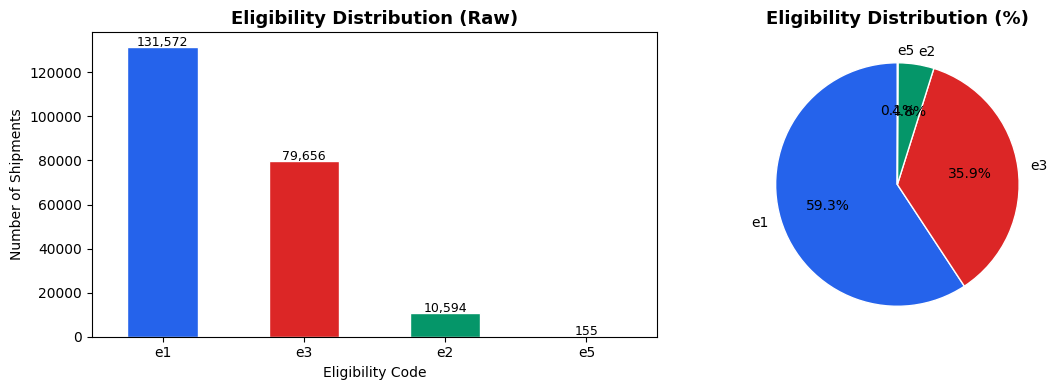

[SAVED] eda_01_eligibility_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

elig_counts.plot(kind='bar', ax=axes[0], color=['#2563EB','#DC2626','#059669','#D97706'],
                 edgecolor='white')
axes[0].set_title('Eligibility Distribution (Raw)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Eligibility Code')
axes[0].set_ylabel('Number of Shipments')
axes[0].tick_params(axis='x', rotation=0)
for bar, count in zip(axes[0].patches, elig_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 500,
                 f'{count:,}', ha='center', fontsize=9)

elig_pct.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
              colors=['#2563EB','#DC2626','#059669','#D97706'],
              startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Eligibility Distribution (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('eda_01_eligibility_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] eda_01_eligibility_distribution.png")

In [ ]:
print("\n--- Top 10 countries of origin (cooalpha) ---")
top_origins = df['cooalpha'].value_counts().head(10)
print(top_origins)


--- Top 10 countries of origin (cooalpha) ---
cooalpha
CN    25386
DE    15394
US    15138
IT    13571
GB    10640
FR     9952
ES     7134
PL     6979
IN     6809
JP     6317
Name: count, dtype: int64


NameError: name 'top_dest' is not defined

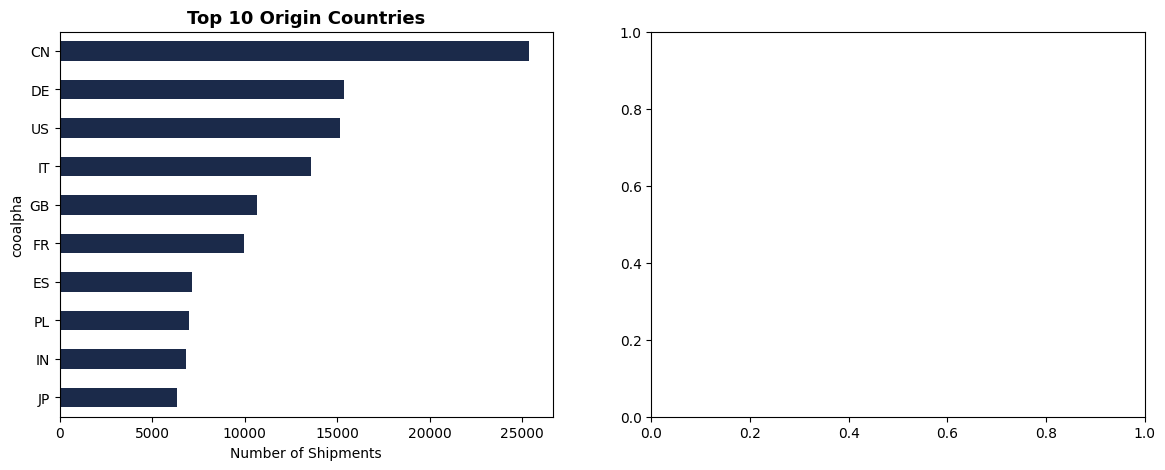

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_origins.plot(kind='barh', ax=axes[0], color='#1B2A4A')
axes[0].set_title('Top 10 Origin Countries', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Shipments')
axes[0].invert_yaxis()

top_dest.plot(kind='barh', ax=axes[1], color='#2563EB')
axes[1].set_title('Top 10 Destination Countries', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Shipments')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('eda_02_top_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] eda_02_top_countries.png")


--- Eligibility breakdown for Top 10 origin countries ---
eligibility     e1    e2    e3
cooalpha                      
CN           25386     0     0
DE            7386     0  8008
ES            2782     0  4352
FR            4381     0  5571
GB           10640     0     0
IN            3787  3022     0
IT            4962     0  8609
JP            3185     0  3132
PL            2860     0  4119
US           15128     0    10


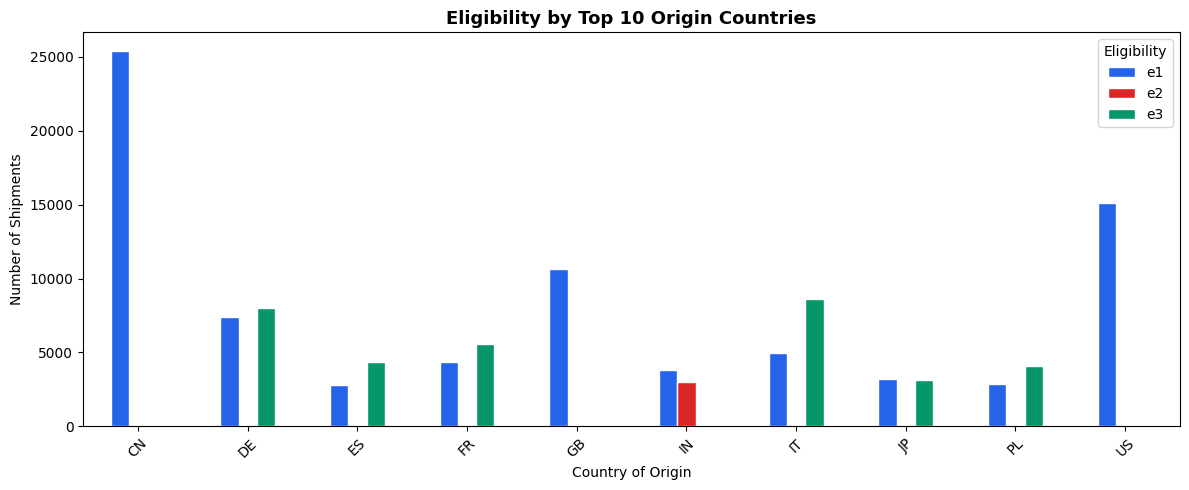

[SAVED] eda_03_eligibility_by_origin.png


In [ ]:
print("\n--- Eligibility breakdown for Top 10 origin countries ---")
top10_origin_list = top_origins.index.tolist()
elig_by_origin = (
    df[df['cooalpha'].isin(top10_origin_list)]
    .groupby(['cooalpha', 'eligibility'])
    .size()
    .unstack(fill_value=0)
)
print(elig_by_origin)

elig_by_origin.plot(kind='bar', figsize=(12, 5),
                    color=['#2563EB','#DC2626','#059669','#D97706'],
                    edgecolor='white')
plt.title('Eligibility by Top 10 Origin Countries', fontsize=13, fontweight='bold')
plt.xlabel('Country of Origin')
plt.ylabel('Number of Shipments')
plt.xticks(rotation=45)
plt.legend(title='Eligibility')
plt.tight_layout()
plt.savefig('eda_03_eligibility_by_origin.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] eda_03_eligibility_by_origin.png")

In [ ]:
print("\n--- Use code distribution ---")
print(df['use'].value_counts())


--- Use code distribution ---
use
u10    102623
u11     71663
u30     43141
u20      3476
u21       891
u31       180
uzz         3
Name: count, dtype: int64



--- statvalue distribution ---
  Min    : £              1
  Mean   : £        269,026
  Median : £          9,882
  Max    : £  4,053,265,711
  Std Dev: £     11,997,582


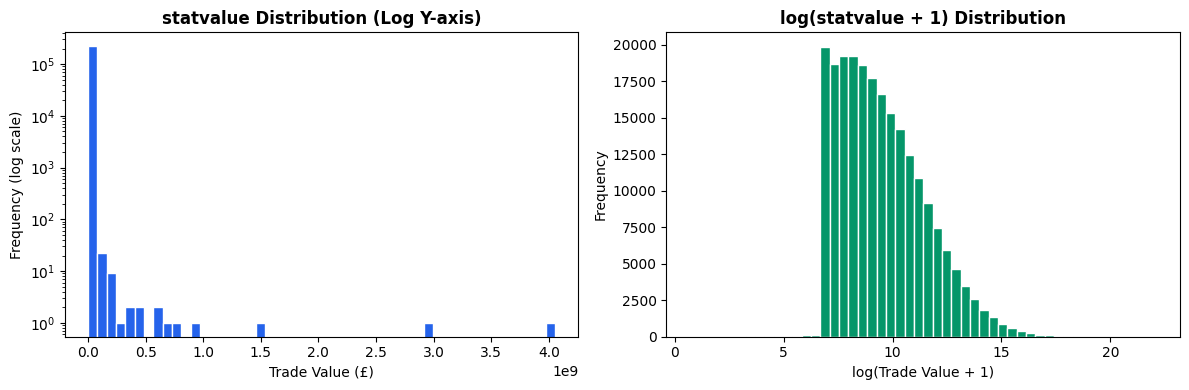

[SAVED] eda_04_statvalue_distribution.png


In [ ]:
print("\n--- statvalue distribution ---")
print(f"  Min    : £{df['statvalue'].min():>15,.0f}")
print(f"  Mean   : £{df['statvalue'].mean():>15,.0f}")
print(f"  Median : £{df['statvalue'].median():>15,.0f}")
print(f"  Max    : £{df['statvalue'].max():>15,.0f}")
print(f"  Std Dev: £{df['statvalue'].std():>15,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['statvalue'], bins=50, color='#2563EB', edgecolor='white', log=True)
axes[0].set_title('statvalue Distribution (Log Y-axis)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Trade Value (£)')
axes[0].set_ylabel('Frequency (log scale)')

log_vals = np.log1p(df['statvalue'])
axes[1].hist(log_vals, bins=50, color='#059669', edgecolor='white')
axes[1].set_title('log(statvalue + 1) Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(Trade Value + 1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('eda_04_statvalue_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] eda_04_statvalue_distribution.png")

In [ ]:
print(f"\n--- Zero-value entries ---")
print(f"  netmass  = 0 : {(df['netmass']  == 0).sum():,} rows ({(df['netmass']==0).mean()*100:.2f}%)")
print(f"  suppunit = 0 : {(df['suppunit'] == 0).sum():,} rows ({(df['suppunit']==0).mean()*100:.2f}%)")
print(f"  statvalue= 0 : {(df['statvalue']== 0).sum():,} rows")

print("\n[INFO] EDA complete — 4 charts saved")


--- Zero-value entries ---
  netmass  = 0 : 4,794 rows (2.16%)
  suppunit = 0 : 160,798 rows (72.44%)
  statvalue= 0 : 0 rows

[INFO] EDA complete — 4 charts saved


In [ ]:
print("\n" + "=" * 65)
print("  STEP 3: DATA CLEANING")
print("=" * 65)

df_clean = df.copy()
original_size = len(df_clean)


  STEP 3: DATA CLEANING


In [ ]:
missing_mask = df_clean['cooalpha'].isna() | df_clean['codalpha'].isna()
df_clean = df_clean[~missing_mask].reset_index(drop=True)
dropped = original_size - len(df_clean)
print(f"\n[CLEAN] Dropped {dropped} rows with missing country codes")
print(f"        Remaining rows: {len(df_clean):,}")


[CLEAN] Dropped 20 rows with missing country codes
        Remaining rows: 221,957


In [ ]:
print(f"\n[CLEAN] Unique perref values: {df_clean['perref'].nunique()}")
df_clean.drop(columns=['perref'], inplace=True)
print(f"        Dropped column 'perref' (constant value 202511 — adds no information)")


[CLEAN] Unique perref values: 1
        Dropped column 'perref' (constant value 202511 — adds no information)


In [ ]:
print(f"\n[CLEAN] Zero netmass entries: {(df_clean['netmass'] == 0).sum():,}")
print(f"        These are valid (digital goods / services) — kept, not dropped")


[CLEAN] Zero netmass entries: 4,791
        These are valid (digital goods / services) — kept, not dropped


In [ ]:
uzz_count = (df_clean['use'] == 'uzz').sum()
df_clean = df_clean[df_clean['use'] != 'uzz'].reset_index(drop=True)
print(f"\n[CLEAN] Removed {uzz_count} rows with use='uzz' (unclassified, negligible)")


[CLEAN] Removed 3 rows with use='uzz' (unclassified, negligible)


In [ ]:
print(f"\n[CLEAN] Dataset size after cleaning: {len(df_clean):,} rows x {df_clean.shape[1]} columns")
print(f"        Rows removed: {original_size - len(df_clean):,} ({(original_size - len(df_clean))/original_size*100:.3f}%)")
print(f"        Remaining missing values: {df_clean.isnull().sum().sum()}")


[CLEAN] Dataset size after cleaning: 221,954 rows x 9 columns
        Rows removed: 23 (0.010%)
        Remaining missing values: 0


In [ ]:
print("\n" + "=" * 65)
print("  STEP 4: FEATURE ENGINEERING")
print("=" * 65)


  STEP 4: FEATURE ENGINEERING


In [ ]:
df_clean['hs_chapter'] = df_clean['comcode'].astype(str).str[:2].astype(int)
print(f"\n[clean] Created 'hs_chapter' (first 2 digits of comcode)")
print(f"       Unique comcodes  : {df_clean['comcode'].nunique():,}")
print(f"       Unique hs_chapters: {df_clean['hs_chapter'].nunique()}")
print(f"       Top 5 chapters:\n{df_clean['hs_chapter'].value_counts().head()}")


[clean] Created 'hs_chapter' (first 2 digits of comcode)
       Unique comcodes  : 8,237
       Unique hs_chapters: 87
       Top 5 chapters:
hs_chapter
84    33094
85    29195
90    14713
62    10516
39     9681
Name: count, dtype: int64


In [ ]:
df_clean['trade_route'] = df_clean['cooalpha'] + '_' + df_clean['codalpha']
print(f"\n[clean] Created 'trade_route' (cooalpha + '_' + codalpha)")
print(f"       Unique trade routes: {df_clean['trade_route'].nunique():,}")
print(f"       Top 5 routes:\n{df_clean['trade_route'].value_counts().head()}")


[clean] Created 'trade_route' (cooalpha + '_' + codalpha)
       Unique trade routes: 4,088
       Top 5 routes:
trade_route
DE_DE    5757
IT_IT    5445
CN_CN    5299
FR_FR    4738
US_US    4489
Name: count, dtype: int64


In [ ]:
df_clean['value_per_kg'] = np.where(
    df_clean['netmass'] > 0,
    df_clean['statvalue'] / df_clean['netmass'],
    0
)
print(f"\n[clean] Created 'value_per_kg' (statvalue / netmass)")
print(f"       Rows where netmass=0 → value_per_kg set to 0: {(df_clean['netmass']==0).sum():,}")
print(f"       value_per_kg statistics:")
print(df_clean['value_per_kg'].describe().round(2))


[clean] Created 'value_per_kg' (statvalue / netmass)
       Rows where netmass=0 → value_per_kg set to 0: 4,791
       value_per_kg statistics:
count      221954.00
mean          713.46
std         29081.55
min             0.00
25%             7.09
50%            30.77
75%           159.77
max      12466950.00
Name: value_per_kg, dtype: float64


In [ ]:
df_clean['log_statvalue'] = np.log1p(df_clean['statvalue'])
df_clean['log_netmass']   = np.log1p(df_clean['netmass'])
df_clean['log_suppunit']  = np.log1p(df_clean['suppunit'])
df_clean['log_value_per_kg'] = np.log1p(df_clean['value_per_kg'])

print(f"\n[clean] Log transformations applied (log1p):")
print(f"       log_statvalue  : mean={df_clean['log_statvalue'].mean():.3f}, std={df_clean['log_statvalue'].std():.3f}")
print(f"       log_netmass    : mean={df_clean['log_netmass'].mean():.3f}, std={df_clean['log_netmass'].std():.3f}")
print(f"       log_suppunit   : mean={df_clean['log_suppunit'].mean():.3f}, std={df_clean['log_suppunit'].std():.3f}")
print(f"       log_value_per_kg: mean={df_clean['log_value_per_kg'].mean():.3f}, std={df_clean['log_value_per_kg'].std():.3f}")


[clean] Log transformations applied (log1p):
       log_statvalue  : mean=9.508, std=1.976
       log_netmass    : mean=5.823, std=3.178
       log_suppunit   : mean=1.359, std=2.781
       log_value_per_kg: mean=3.690, std=2.115


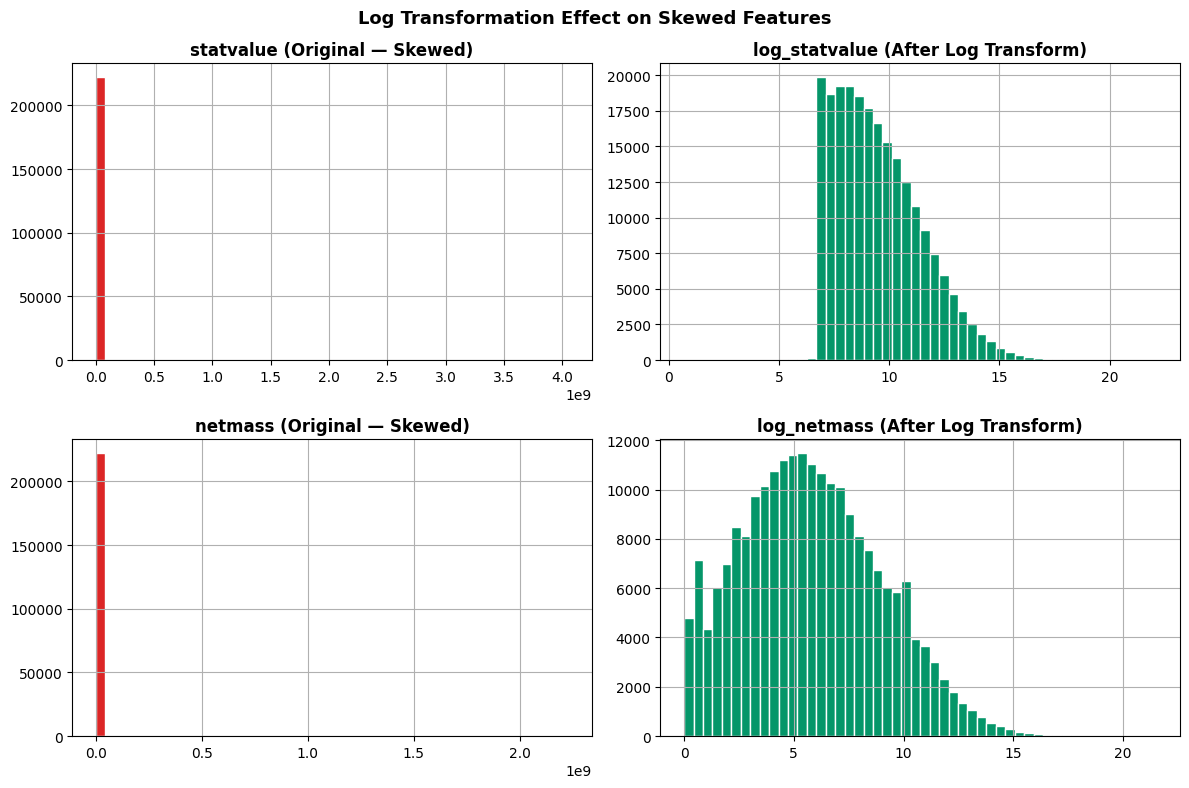

[SAVED] feat_01_log_transforms.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
cols_before = ['statvalue','netmass']
cols_after  = ['log_statvalue','log_netmass']

for i, (before, after) in enumerate(zip(cols_before, cols_after)):
    df_clean[before].hist(bins=50, ax=axes[i][0], color='#DC2626', edgecolor='white')
    axes[i][0].set_title(f'{before} (Original — Skewed)', fontweight='bold')

    df_clean[after].hist(bins=50, ax=axes[i][1], color='#059669', edgecolor='white')
    axes[i][1].set_title(f'{after} (After Log Transform)', fontweight='bold')

plt.suptitle('Log Transformation Effect on Skewed Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feat_01_log_transforms.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] feat_01_log_transforms.png")

In [ ]:
print(f"\n[clean] All features after engineering:")
for col in df_clean.columns:
    print(f"       {col:<25} | dtype: {str(df_clean[col].dtype):<10} | unique: {df_clean[col].nunique()}")


[clean] All features after engineering:
       cooalpha                  | dtype: object     | unique: 215
       codalpha                  | dtype: object     | unique: 199
       comcode                   | dtype: int64      | unique: 8237
       statreg                   | dtype: int64      | unique: 3
       eligibility               | dtype: object     | unique: 4
       use                       | dtype: object     | unique: 6
       statvalue                 | dtype: int64      | unique: 86731
       netmass                   | dtype: int64      | unique: 36728
       suppunit                  | dtype: int64      | unique: 11810
       hs_chapter                | dtype: int64      | unique: 87
       trade_route               | dtype: object     | unique: 4088
       value_per_kg              | dtype: float64    | unique: 190373
       log_statvalue             | dtype: float64    | unique: 86731
       log_netmass               | dtype: float64    | unique: 36728
       log_su

In [ ]:
print("\n" + "=" * 65)
print("  STEP 5: TARGET VARIABLE ENCODING")
print("=" * 65)


  STEP 5: TARGET VARIABLE ENCODING


In [ ]:
eligibility_map = {'e1': 1, 'e2': 1, 'e3': 0, 'e5': 0}
df_clean['target'] = df_clean['eligibility'].map(eligibility_map)

print(f"\n[TARGET] Encoding: e1→1, e2→1 (Eligible) | e3→0, e5→0 (Not Eligible)")
target_dist = df_clean['target'].value_counts()
target_pct  = df_clean['target'].value_counts(normalize=True) * 100
print(pd.DataFrame({
    'Label'     : {1: 'Eligible (1)', 0: 'Not Eligible (0)'},
    'Count'     : target_dist,
    'Percentage': target_pct.round(2)
}))

class_ratio = target_dist[1] / target_dist[0]
print(f"\n[INFO] Class ratio (eligible:not eligible) = {class_ratio:.2f}:1")
print(f"       Imbalance is mild — stratified split is sufficient (no SMOTE needed)")


[TARGET] Encoding: e1→1, e2→1 (Eligible) | e3→0, e5→0 (Not Eligible)
              Label   Count  Percentage
1      Eligible (1)  142147       64.04
0  Not Eligible (0)   79807       35.96

[INFO] Class ratio (eligible:not eligible) = 1.78:1
       Imbalance is mild — stratified split is sufficient (no SMOTE needed)


In [ ]:
print("\n" + "=" * 65)
print("  STEP 6: CATEGORICAL FEATURE ENCODING")
print("=" * 65)

df_enc = df_clean.copy()


  STEP 6: CATEGORICAL FEATURE ENCODING


In [ ]:
print("\n[ENCODE] One-Hot Encoding: statreg, use")
df_enc = pd.get_dummies(df_enc,
                         columns=['statreg', 'use'],
                         prefix=['statreg', 'use'],
                         drop_first=False)

new_ohe_cols = [c for c in df_enc.columns if c.startswith('statreg_') or c.startswith('use_')]
print(f"         Columns created: {new_ohe_cols}")


[ENCODE] One-Hot Encoding: statreg, use
         Columns created: ['statreg_1', 'statreg_2', 'statreg_3', 'use_u10', 'use_u11', 'use_u20', 'use_u21', 'use_u30', 'use_u31']


In [ ]:
print("\n[ENCODE] Label Encoding: cooalpha, codalpha, trade_route")
le_coo   = LabelEncoder()
le_cod   = LabelEncoder()
le_route = LabelEncoder()

df_enc['cooalpha_enc']    = le_coo.fit_transform(df_enc['cooalpha'])
df_enc['codalpha_enc']    = le_cod.fit_transform(df_enc['codalpha'])
df_enc['trade_route_enc'] = le_route.fit_transform(df_enc['trade_route'])

print(f"         cooalpha    → {df_enc['cooalpha_enc'].nunique()} encoded values (0–{df_enc['cooalpha_enc'].max()})")
print(f"         codalpha    → {df_enc['codalpha_enc'].nunique()} encoded values (0–{df_enc['codalpha_enc'].max()})")
print(f"         trade_route → {df_enc['trade_route_enc'].nunique()} encoded values")


[ENCODE] Label Encoding: cooalpha, codalpha, trade_route
         cooalpha    → 215 encoded values (0–214)
         codalpha    → 199 encoded values (0–198)
         trade_route → 4088 encoded values


In [ ]:

cols_to_drop = [
    'cooalpha', 'codalpha', 'comcode',
    'eligibility', 'trade_route',
    'statvalue', 'netmass', 'suppunit', 'value_per_kg'
    # ^ dropping originals — keeping log-transformed versions
]
df_enc.drop(columns=cols_to_drop, inplace=True)
print(f"\n[ENCODE] Dropped original/intermediate columns: {cols_to_drop}")


[ENCODE] Dropped original/intermediate columns: ['cooalpha', 'codalpha', 'comcode', 'eligibility', 'trade_route', 'statvalue', 'netmass', 'suppunit', 'value_per_kg']


In [ ]:
feature_cols = [c for c in df_enc.columns if c != 'target']
print(f"\n[ENCODE] Final feature matrix: {len(df_enc):,} rows × {len(feature_cols)} features")
print(f"         Features:")
for col in feature_cols:
    print(f"           {col}")


[ENCODE] Final feature matrix: 221,954 rows × 17 features
         Features:
           hs_chapter
           log_statvalue
           log_netmass
           log_suppunit
           log_value_per_kg
           statreg_1
           statreg_2
           statreg_3
           use_u10
           use_u11
           use_u20
           use_u21
           use_u30
           use_u31
           cooalpha_enc
           codalpha_enc
           trade_route_enc


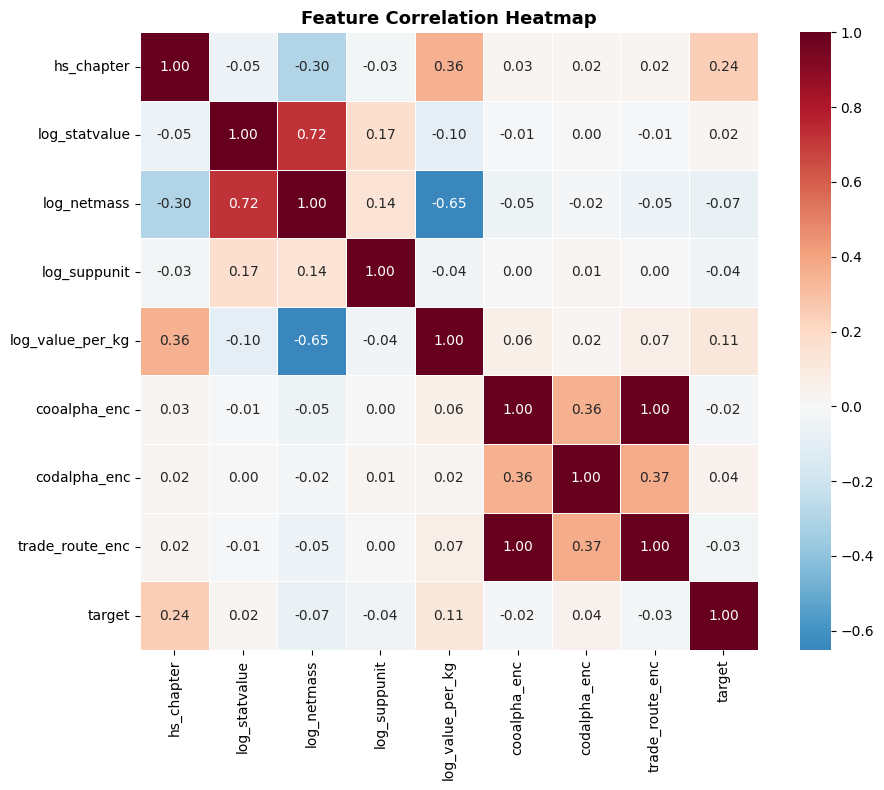

[SAVED] clean_02_correlation_heatmap.png


In [ ]:
num_features = ['hs_chapter','log_statvalue','log_netmass',
                'log_suppunit','log_value_per_kg',
                'cooalpha_enc','codalpha_enc','trade_route_enc','target']
corr = df_enc[num_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('clean_02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] clean_02_correlation_heatmap.png")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
print("\n" + "=" * 65)
print("  STEP 7: TRAIN / TEST SPLIT")
print("=" * 65)

# Define X (features) as DataFrame, y (target) as Series to preserve index for splitting
X_df = df_enc[feature_cols]
y_s  = df_enc['target']

print(f"\n[SPLIT] Feature matrix X shape : {X_df.shape}")
print(f"[SPLIT] Target vector  y shape : {y_s.shape}")
print(f"[SPLIT] Class distribution in y:")
unique, counts = np.unique(y_s, return_counts=True)
for cls, cnt in zip(unique, counts):
    label = 'Eligible' if cls == 1 else 'Not Eligible'
    print(f"         {cls} ({label:<15}): {cnt:,} ({cnt/len(y_s)*100:.2f}%)")


  STEP 7: TRAIN / TEST SPLIT

[SPLIT] Feature matrix X shape : (221954, 17)
[SPLIT] Target vector  y shape : (221954,)
[SPLIT] Class distribution in y:
         0 (Not Eligible   ): 79,807 (35.96%)
         1 (Eligible       ): 142,147 (64.04%)


In [ ]:
# Perform the split on DataFrames/Series to easily retain indices
X_train_df, X_test_df, y_train_s, y_test_s = train_test_split(
    X_df, y_s,
    test_size=0.20,
    random_state=42,
    stratify=y_s          # critical: maintains class balance
)

# Convert to numpy arrays for models that expect it, to match existing code
X_train = X_train_df.values
X_test = X_test_df.values
y_train = y_train_s.values
y_test = y_test_s.values

# Store the original data for the test set for KPI generation
# This uses the indices from X_test_df to select corresponding rows from df_clean
df_test_original = df_clean.loc[X_test_df.index].copy()

print(f"\n[SPLIT] Training set  : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X_df)*100:.1f}%)")
print(f"[SPLIT] Test set      : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X_df)*100:.1f}%)")

# Verify stratification
train_pos = y_train.sum() / len(y_train) * 100
test_pos  = y_test.sum()  / len(y_test)  * 100
print(f"\n[VERIFY] Eligible % in training set : {train_pos:.2f}%")
print(f"[VERIFY] Eligible % in test set     : {test_pos:.2f}%")
print(f"[VERIFY] Stratification preserved ✓" if abs(train_pos - test_pos) < 0.5 else "[WARN] Stratification mismatch!")


[SPLIT] Training set  : 177,563 rows (80.0%)
[SPLIT] Test set      : 44,391 rows (20.0%)

[VERIFY] Eligible % in training set : 64.04%
[VERIFY] Eligible % in test set     : 64.04%
[VERIFY] Stratification preserved ✓


In [ ]:
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on training data ONLY
X_test_scaled  = scaler.transform(X_test)       # apply same scaling to test

print(f"\n[SCALE] StandardScaler applied")
print(f"        Fitted on training set only (prevents data leakage)")
print(f"        X_train_scaled: mean≈0, std≈1 per feature")
print(f"        X_test_scaled : same transformation applied")

print(f"\n[INFO] Feature list used for all models:")
for i, col in enumerate(feature_cols):
    print(f"       {i+1:>2}. {col}")


[SCALE] StandardScaler applied
        Fitted on training set only (prevents data leakage)
        X_train_scaled: mean≈0, std≈1 per feature
        X_test_scaled : same transformation applied

[INFO] Feature list used for all models:
        1. hs_chapter
        2. log_statvalue
        3. log_netmass
        4. log_suppunit
        5. log_value_per_kg
        6. statreg_1
        7. statreg_2
        8. statreg_3
        9. use_u10
       10. use_u11
       11. use_u20
       12. use_u21
       13. use_u30
       14. use_u31
       15. cooalpha_enc
       16. codalpha_enc
       17. trade_route_enc


In [ ]:
def evaluate_model(model_name, y_true, y_pred, y_prob=None):
    """
    Prints and plots a full evaluation report for a classifier.

    Parameters
    ----------
    model_name : str
        Name of the model for display purposes.
    y_true     : array-like
        True binary labels (0 or 1).
    y_pred     : array-like
        Predicted binary labels (0 or 1).
    y_prob     : array-like or None
        Predicted probabilities for the positive class.
        If provided, ROC-AUC is computed.
    """
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='weighted')
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else None
    cm   = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n{'='*55}")
    print(f"  RESULTS: {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy     : {acc*100:.2f}%")
    print(f"  F1-Score     : {f1:.4f}")
    if auc:
        print(f"  ROC-AUC      : {auc:.4f}")
    print(f"  True Positives  (TP): {tp:,}  — correctly predicted eligible")
    print(f"  True Negatives  (TN): {tn:,}  — correctly predicted not eligible")
    print(f"  False Positives (FP): {fp:,}  — predicted eligible, actually not")
    print(f"  False Negatives (FN): {fn:,}  — predicted not eligible, actually eligible")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred,
                                 target_names=['Not Eligible (0)', 'Eligible (1)']))

    # Confusion matrix plot
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Not Eligible', 'Eligible'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    fname = f'cm_{model_name.lower().replace(" ","_").replace("/","_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"[SAVED] {fname}")

    return {'model': model_name, 'accuracy': acc, 'f1': f1, 'auc': auc}


# Collect all results for final comparison
results = []

In [ ]:
print("\n" + "=" * 65)
print("  MODEL 1: LOGISTIC REGRESSION — BASELINE")
print("=" * 65)


  MODEL 1: LOGISTIC REGRESSION — BASELINE



  MODEL 1: LOGISTIC REGRESSION — BASELINE

[LR] Training Logistic Regression...
[LR] Training complete

  RESULTS: Logistic Regression
  Accuracy     : 86.87%
  F1-Score     : 0.8686
  ROC-AUC      : 0.9587
  True Positives  (TP): 25,557  — correctly predicted eligible
  True Negatives  (TN): 13,004  — correctly predicted not eligible
  False Positives (FP): 2,957  — predicted eligible, actually not
  False Negatives (FN): 2,873  — predicted not eligible, actually eligible

  Classification Report:
                  precision    recall  f1-score   support

Not Eligible (0)       0.82      0.81      0.82     15961
    Eligible (1)       0.90      0.90      0.90     28430

        accuracy                           0.87     44391
       macro avg       0.86      0.86      0.86     44391
    weighted avg       0.87      0.87      0.87     44391



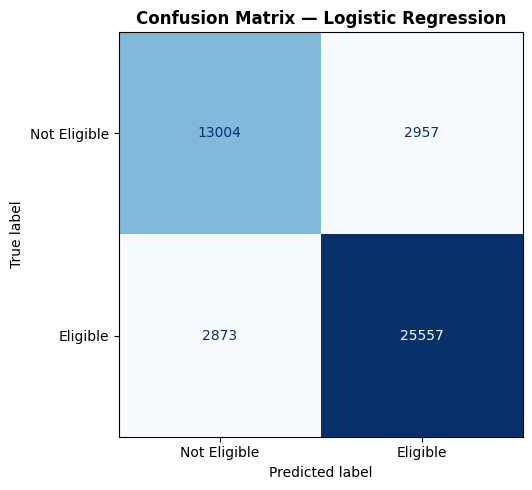

[SAVED] cm_logistic_regression.png

[LR] Top 10 most influential features (by coefficient magnitude):
        Feature  Coefficient
        use_u30    -5.970949
trade_route_enc    -4.963050
   cooalpha_enc     4.713929
        use_u10     3.686434
        use_u21     1.336090
        use_u20     0.790361
        use_u11     0.753924
        use_u31    -0.410496
   codalpha_enc     0.274658
    log_netmass     0.260968


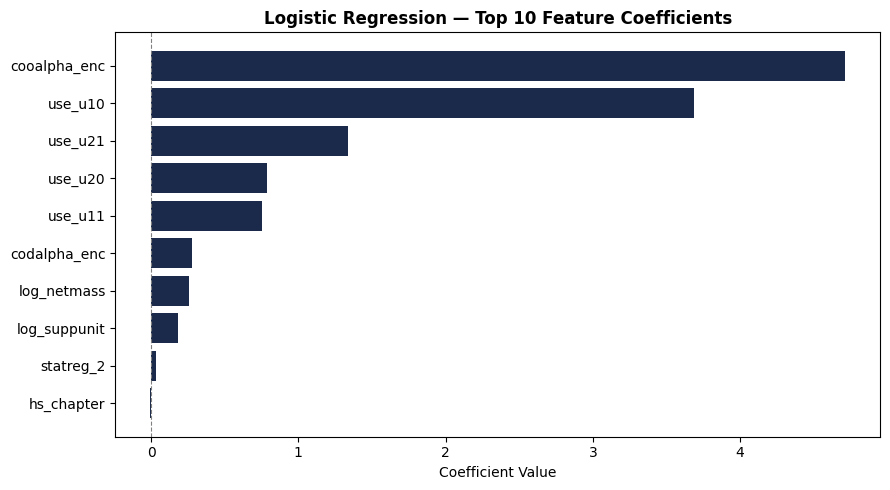

[SAVED] lr_feature_coefficients.png


In [ ]:

print("\n" + "=" * 65)
print("  MODEL 1: LOGISTIC REGRESSION — BASELINE")
print("=" * 65)

# Why Logistic Regression?
# - Simplest classification algorithm → establishes performance floor
# - Any complex model must clearly beat this to justify added complexity
# - Fully interpretable coefficients show which features drive predictions
# - Uses scaled features (important for LR)

print("\n[LR] Training Logistic Regression...")
lr_model = LogisticRegression(
    C=1.0,              # regularisation strength (1/lambda) — default
    penalty='l2',       # L2 (Ridge) regularisation — penalises large coefficients
    solver='lbfgs',     # efficient solver for multiclass + L2
    max_iter=1000,      # ensure convergence
    random_state=42,
    n_jobs=-1           # use all CPU cores
)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]  # probability for class 1

print("[LR] Training complete")
res_lr = evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)
results.append(res_lr)

# Feature importance (coefficients)
print("\n[LR] Top 10 most influential features (by coefficient magnitude):")
coef_df = pd.DataFrame({
    'Feature'    : feature_cols,
    'Coefficient': lr_model.coef_[0]
}).reindex(lr_model.coef_[0].argsort()[::-1])
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.nlargest(10, 'Abs_Coefficient')
print(coef_df[['Feature','Coefficient']].to_string(index=False))

plt.figure(figsize=(9, 5))
coef_df_plot = pd.DataFrame({
    'Feature'    : feature_cols,
    'Coefficient': lr_model.coef_[0]
}).nlargest(10, 'Coefficient')
plt.barh(coef_df_plot['Feature'], coef_df_plot['Coefficient'], color='#1B2A4A')
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Logistic Regression — Top 10 Feature Coefficients', fontweight='bold')
plt.xlabel('Coefficient Value')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('lr_feature_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] lr_feature_coefficients.png")

In [ ]:
print("\n" + "=" * 65)
print("  MODEL 2: RANDOM FOREST — PRIMARY MODEL")
print("=" * 65)


  MODEL 2: RANDOM FOREST — PRIMARY MODEL



[RF] Training Random Forest (this may take 1-2 minutes)...
[RF] Training complete

  RESULTS: Random Forest
  Accuracy     : 99.19%
  F1-Score     : 0.9919
  ROC-AUC      : 0.9992
  True Positives  (TP): 28,163  — correctly predicted eligible
  True Negatives  (TN): 15,867  — correctly predicted not eligible
  False Positives (FP): 94  — predicted eligible, actually not
  False Negatives (FN): 267  — predicted not eligible, actually eligible

  Classification Report:
                  precision    recall  f1-score   support

Not Eligible (0)       0.98      0.99      0.99     15961
    Eligible (1)       1.00      0.99      0.99     28430

        accuracy                           0.99     44391
       macro avg       0.99      0.99      0.99     44391
    weighted avg       0.99      0.99      0.99     44391



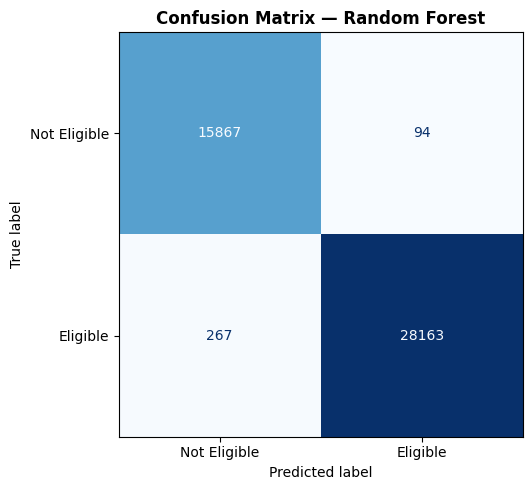

[SAVED] cm_random_forest.png


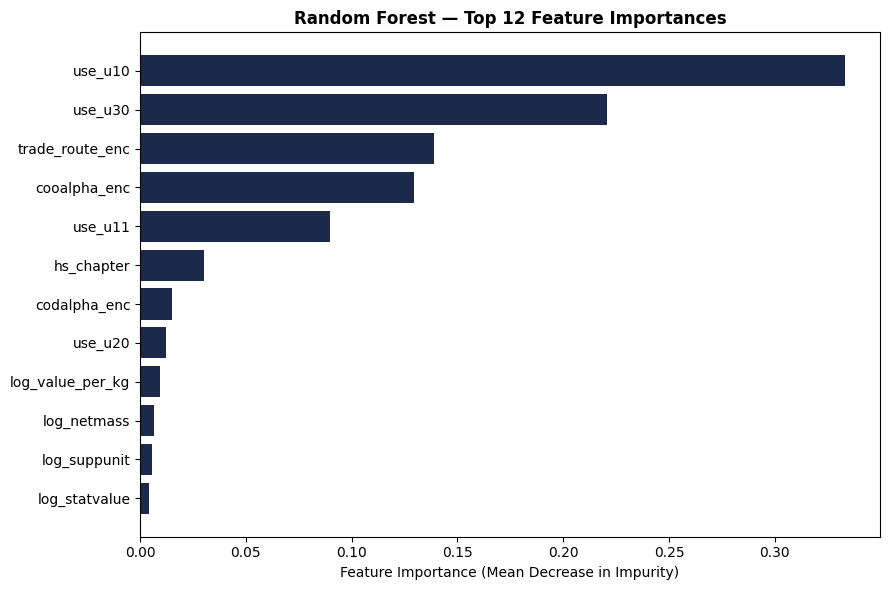

[SAVED] rf_feature_importance.png

[RF] Top 12 most important features:
         Feature  Importance
         use_u10    0.333117
         use_u30    0.220696
 trade_route_enc    0.138743
    cooalpha_enc    0.129555
         use_u11    0.089823
      hs_chapter    0.030116
    codalpha_enc    0.015275
         use_u20    0.012246
log_value_per_kg    0.009302
     log_netmass    0.006364
    log_suppunit    0.005849
   log_statvalue    0.004058


In [ ]:

print("\n[RF] Training Random Forest (this may take 1-2 minutes)...")
rf_model = RandomForestClassifier(
    n_estimators=200,        # number of trees — more = better but slower
    max_depth=20,            # maximum depth of each tree
    min_samples_split=10,    # minimum samples needed to split a node
    min_samples_leaf=5,      # minimum samples in each leaf node
    max_features='sqrt',     # number of features to consider at each split
    class_weight='balanced', # handles mild class imbalance automatically
    random_state=42,
    n_jobs=-1                # use all CPU cores for parallel training
)

rf_model.fit(X_train, y_train)   # No scaling needed for RF

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("[RF] Training complete")
res_rf = evaluate_model("Random Forest", y_test, rf_pred, rf_prob)
results.append(res_rf)

# Feature importance plot
rf_importances = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(12)

plt.figure(figsize=(9, 6))
plt.barh(rf_importances['Feature'], rf_importances['Importance'], color='#1B2A4A')
plt.title('Random Forest — Top 12 Feature Importances', fontweight='bold')
plt.xlabel('Feature Importance (Mean Decrease in Impurity)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] rf_feature_importance.png")
print("\n[RF] Top 12 most important features:")
print(rf_importances.to_string(index=False))

In [ ]:
print("\n" + "=" * 65)
print("  MODEL 3: XGBOOST — PRIMARY MODEL + SHAP EXPLAINABILITY")
print("=" * 65)


  MODEL 3: XGBOOST — PRIMARY MODEL + SHAP EXPLAINABILITY



[XGB] Training XGBoost...
[XGB] Training complete

  RESULTS: XGBoost
  Accuracy     : 99.67%
  F1-Score     : 0.9967
  ROC-AUC      : 0.9997
  True Positives  (TP): 28,353  — correctly predicted eligible
  True Negatives  (TN): 15,892  — correctly predicted not eligible
  False Positives (FP): 69  — predicted eligible, actually not
  False Negatives (FN): 77  — predicted not eligible, actually eligible

  Classification Report:
                  precision    recall  f1-score   support

Not Eligible (0)       1.00      1.00      1.00     15961
    Eligible (1)       1.00      1.00      1.00     28430

        accuracy                           1.00     44391
       macro avg       1.00      1.00      1.00     44391
    weighted avg       1.00      1.00      1.00     44391



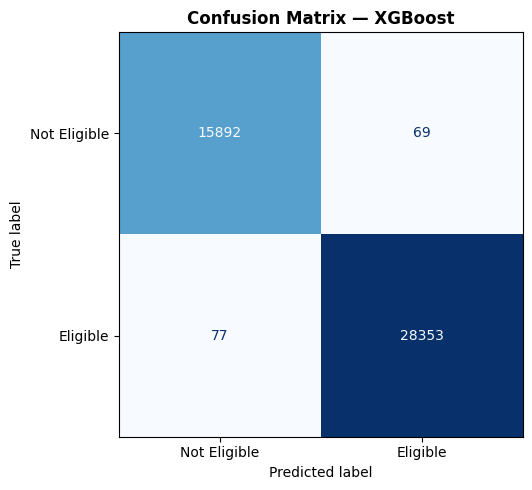

[SAVED] cm_xgboost.png


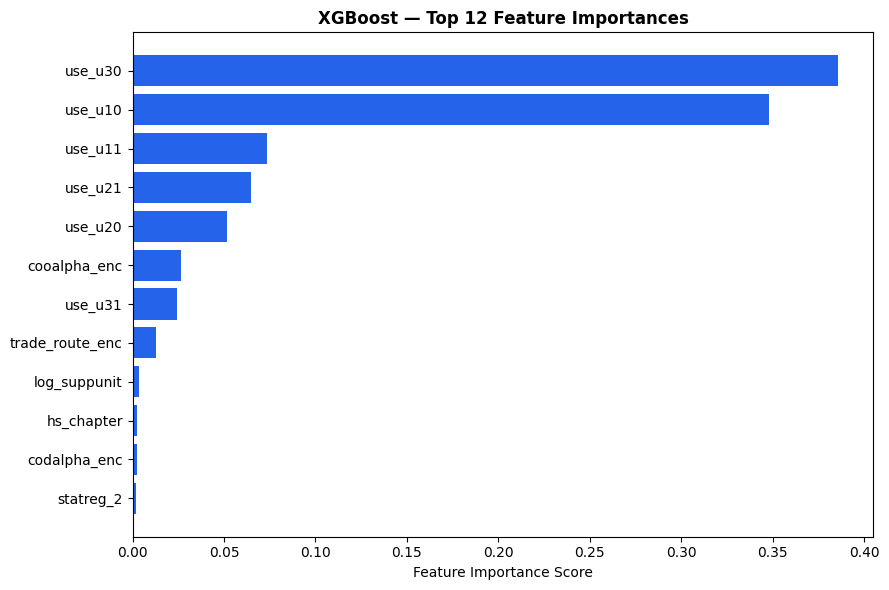

[SAVED] xgb_feature_importance.png

[SHAP] Computing SHAP values (this may take ~30 seconds)...
       SHAP = SHapley Additive exPlanations
       Tells us WHY the model made each prediction


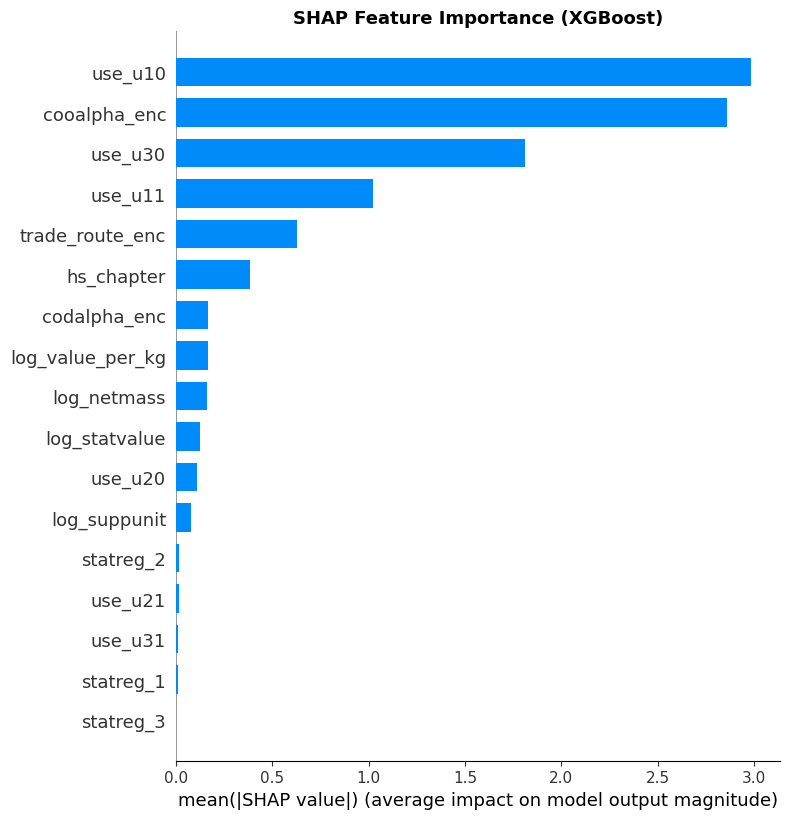

[SAVED] shap_summary_bar.png


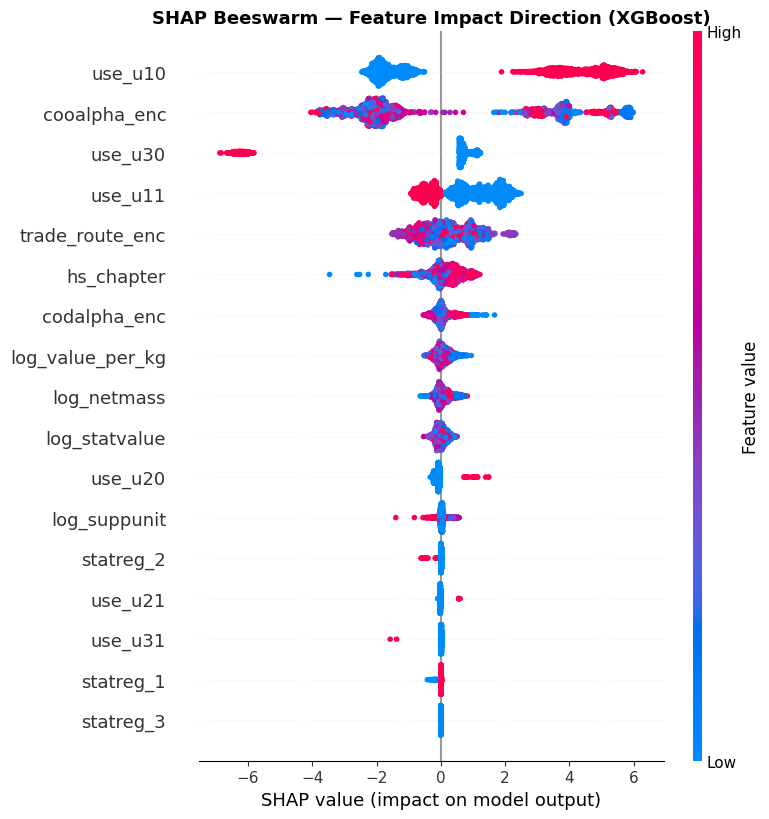

[SAVED] shap_summary_beeswarm.png

[SHAP] Explaining a single prediction (waterfall plot):
       Shipment sample index: 10665
       True label : Not Eligible
       Predicted  : Not Eligible
       Probability: 0.0008


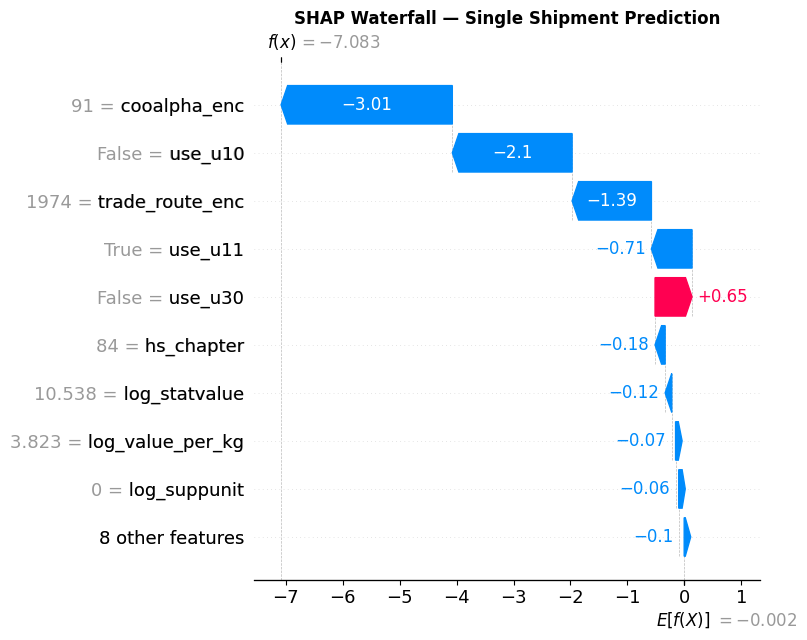

[SAVED] shap_waterfall_single.png


In [ ]:

print("\n[XGB] Training XGBoost...")
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
# scale_pos_weight handles class imbalance in XGBoost
# = number of negatives / number of positives

xgb_model = xgb.XGBClassifier(
    n_estimators=300,           # number of boosting rounds
    max_depth=6,                # maximum tree depth
    learning_rate=0.1,          # shrinkage — prevents overfitting
    subsample=0.8,              # fraction of training data per tree
    colsample_bytree=0.8,       # fraction of features per tree
    min_child_weight=5,         # minimum sum of weights in a child node
    gamma=0.1,                  # minimum loss reduction for split
    reg_alpha=0.1,              # L1 regularisation (Lasso)
    reg_lambda=1.0,             # L2 regularisation (Ridge)
    scale_pos_weight=scale_pos_weight,  # handles class imbalance
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("[XGB] Training complete")
res_xgb = evaluate_model("XGBoost", y_test, xgb_pred, xgb_prob)
results.append(res_xgb)

# ── XGBoost built-in feature importance ──────────────────────────────────────
xgb_imp = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(12)

plt.figure(figsize=(9, 6))
plt.barh(xgb_imp['Feature'], xgb_imp['Importance'], color='#2563EB')
plt.title('XGBoost — Top 12 Feature Importances', fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] xgb_feature_importance.png")

# ── SHAP Explainability ───────────────────────────────────────────────────────
print("\n[SHAP] Computing SHAP values (this may take ~30 seconds)...")
print("       SHAP = SHapley Additive exPlanations")
print("       Tells us WHY the model made each prediction")

# Use a sample of 2,000 test rows for speed (SHAP on all 44k rows is slow)
shap_sample_size = 2000
np.random.seed(42)
shap_idx = np.random.choice(len(X_test), size=shap_sample_size, replace=False)
X_test_shap = X_test[shap_idx]

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_shap)

# SHAP summary plot — shows which features matter most across all predictions
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test_shap,
    feature_names=feature_cols,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance (XGBoost)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] shap_summary_bar.png")

# SHAP beeswarm plot — shows direction and magnitude of each feature's impact
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test_shap,
    feature_names=feature_cols,
    show=False
)
plt.title('SHAP Beeswarm — Feature Impact Direction (XGBoost)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] shap_summary_beeswarm.png")

# SHAP waterfall for a single prediction (most interpretable for a manager)
print("\n[SHAP] Explaining a single prediction (waterfall plot):")
sample_idx = 0
print(f"       Shipment sample index: {shap_idx[sample_idx]}")
print(f"       True label : {'Eligible'     if y_test[shap_idx[sample_idx]]==1 else 'Not Eligible'}")
print(f"       Predicted  : {'Eligible'     if xgb_pred[shap_idx[sample_idx]]==1 else 'Not Eligible'}")
print(f"       Probability: {xgb_prob[shap_idx[sample_idx]]:.4f}")

explanation = shap.Explanation(
    values    = shap_values[sample_idx],
    base_values = explainer.expected_value,
    data      = X_test_shap[sample_idx],
    feature_names = feature_cols
)
plt.figure(figsize=(10, 5))
shap.plots.waterfall(explanation, show=False)
plt.title('SHAP Waterfall — Single Shipment Prediction', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall_single.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] shap_waterfall_single.png")

In [ ]:
print("\n" + "=" * 65)
print("  MODEL 4: LSTM / RNN — DEEP LEARNING MODEL")
print("=" * 65)


  MODEL 4: LSTM / RNN — DEEP LEARNING MODEL



[LSTM] Input shape : (177563, 1, 17)
       (samples, timesteps=1, features=17)


Model: "LSTM_SCM_Delay_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_layer (LSTM)               │ (None, 64)             │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,105 (90.25 KB)

 Trainable params: 23,105 (90.25 KB)

 Non-trainable params: 0 (0.00 B)


[LSTM] Training LSTM model...
Epoch 1/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8309 - auc: 0.9414 - loss: 0.2144 - precision: 0.9694 - recall: 0.7599 - val_accuracy: 0.8806 - val_auc: 0.9685 - val_loss: 0.2228 - val_precision: 0.9707 - val_recall: 0.8392
Epoch 2/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8782 - auc: 0.9658 - loss: 0.1484 - precision: 0.9636 - recall: 0.8416 - val_accuracy: 0.8864 - val_auc: 0.9697 - val_loss: 0.2173 - val_precision: 0.9666 - val_recall: 0.8523
Epoch 3/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8800 - auc: 0.9669 - loss: 0.1466 - precision: 0.9639 - recall: 0.8443 - val_accuracy: 0.8854 - val_auc: 0.9703 - val_loss: 0.2161 - val_precision: 0.9680 - val_recall: 0.8494
Epoch 4/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8800 - auc: 0.9677 - loss: 0.1453 - precision: 0.9661 - recall: 0.8421 - val_accuracy: 0.8843 - val_auc: 0.9709 - val_loss: 0.2154 - val_precision: 0.9705 - val_recall: 0.845

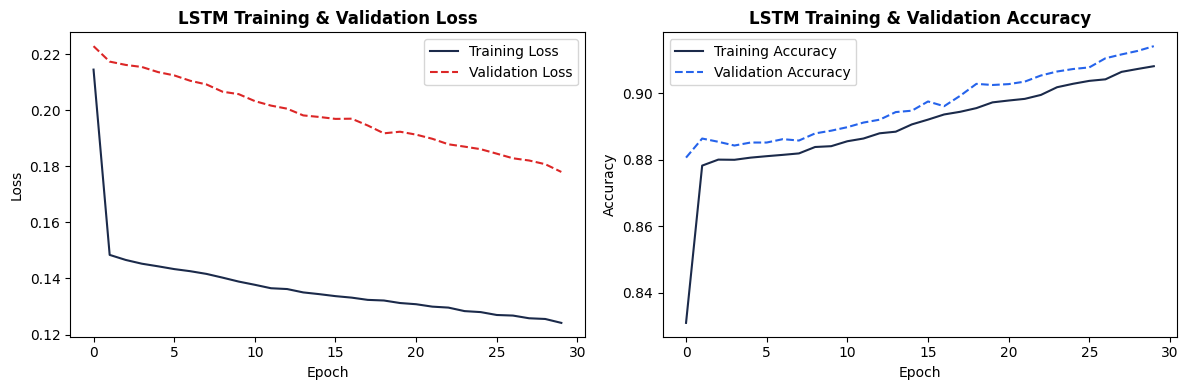

[SAVED] lstm_training_history.png

  RESULTS: LSTM / RNN
  Accuracy     : 91.15%
  F1-Score     : 0.9126
  ROC-AUC      : 0.9813
  True Positives  (TP): 25,340  — correctly predicted eligible
  True Negatives  (TN): 15,121  — correctly predicted not eligible
  False Positives (FP): 840  — predicted eligible, actually not
  False Negatives (FN): 3,090  — predicted not eligible, actually eligible

  Classification Report:
                  precision    recall  f1-score   support

Not Eligible (0)       0.83      0.95      0.88     15961
    Eligible (1)       0.97      0.89      0.93     28430

        accuracy                           0.91     44391
       macro avg       0.90      0.92      0.91     44391
    weighted avg       0.92      0.91      0.91     44391



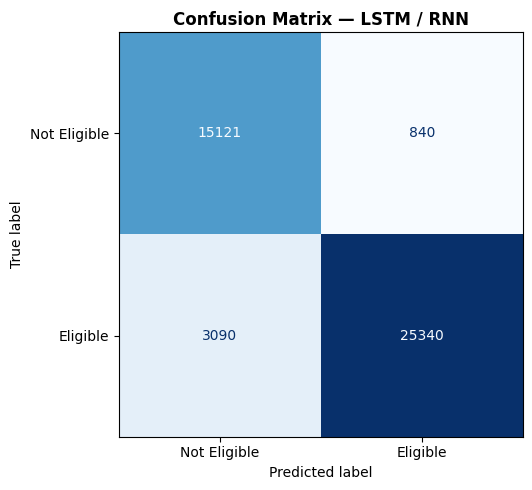

[SAVED] cm_lstm___rnn.png


In [ ]:
n_features = X_train_scaled.shape[1]

# Reshape for LSTM: [samples, timesteps=1, features]
X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], 1, n_features)
X_test_lstm  = X_test_scaled.reshape(X_test_scaled.shape[0],  1, n_features)

print(f"\n[LSTM] Input shape : {X_train_lstm.shape}")
print(f"       (samples, timesteps=1, features={n_features})")

# Build LSTM architecture
tf.random.set_seed(42)

lstm_model = Sequential([
    # LSTM layer: 64 units, returns sequences=False (single output)
    LSTM(64,
         input_shape=(1, n_features),
         return_sequences=False,
         name='lstm_layer'),

    # Dropout: randomly drops 30% of neurons during training → prevents overfitting
    Dropout(0.3, name='dropout_1'),

    # Dense hidden layer: 32 neurons, ReLU activation
    Dense(32, activation='relu', name='dense_1'),

    # Second dropout layer
    Dropout(0.2, name='dropout_2'),

    # Output layer: 1 neuron, sigmoid → outputs probability between 0 and 1
    Dense(1, activation='sigmoid', name='output')
], name='LSTM_SCM_Delay_Model')

lstm_model.summary()

# Compile with binary cross-entropy loss (standard for binary classification)
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

# Early stopping: stop training if validation loss does not improve for 5 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,  # restore weights from best epoch
    verbose=1
)

print("\n[LSTM] Training LSTM model...")
history = lstm_model.fit(
    X_train_lstm, y_train,
    epochs=30,              # maximum epochs
    batch_size=512,         # larger batch = faster training
    validation_split=0.15,  # 15% of training data used for validation
    callbacks=[early_stop],
    class_weight={0: 1.0, 1: 0.5},  # mild upweighting of not-eligible class
    verbose=1
)

print(f"\n[LSTM] Training stopped at epoch {len(history.history['loss'])}")

# Training history plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Training Loss',   color='#1B2A4A')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='#DC2626', linestyle='--')
axes[0].set_title('LSTM Training & Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Training Accuracy',   color='#1B2A4A')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='#2563EB', linestyle='--')
axes[1].set_title('LSTM Training & Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] lstm_training_history.png")

# Evaluate LSTM
lstm_prob_raw = lstm_model.predict(X_test_lstm, verbose=0).flatten()
lstm_pred     = (lstm_prob_raw >= 0.5).astype(int)

res_lstm = evaluate_model("LSTM / RNN", y_test, lstm_pred, lstm_prob_raw)
results.append(res_lstm)


  FINAL COMPARISON — ALL 4 MODELS

              model  accuracy_pct  f1_rounded  auc_rounded
Logistic Regression         86.87      0.8686       0.9587
      Random Forest         99.19      0.9919       0.9992
            XGBoost         99.67      0.9967       0.9997
         LSTM / RNN         91.15      0.9126       0.9813


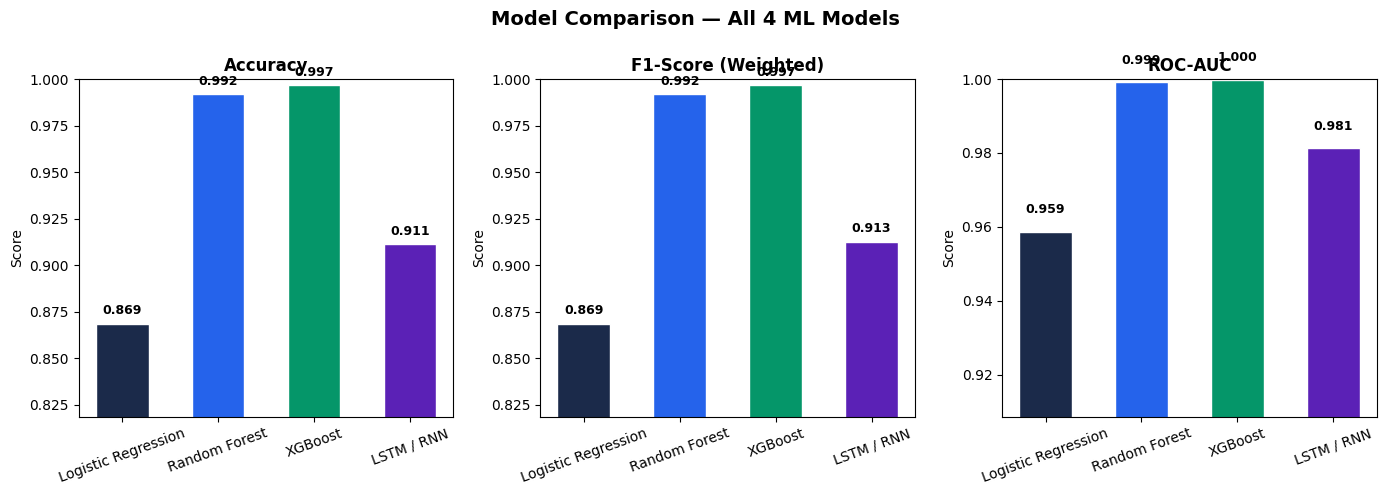

[SAVED] model_comparison_final.png

  PIPELINE COMPLETE

  Best Model   : XGBoost
  F1-Score     : 0.9967
  Accuracy     : 99.67%
  ROC-AUC      : 0.9997

  Charts saved:
    → eda_01_eligibility_distribution.png
    → eda_02_top_countries.png
    → eda_03_eligibility_by_origin.png
    → eda_04_statvalue_distribution.png
    → feat_01_log_transforms.png
    → feat_02_correlation_heatmap.png
    → cm_logistic_regression.png
    → lr_feature_coefficients.png
    → cm_random_forest.png
    → rf_feature_importance.png
    → cm_xgboost.png
    → xgb_feature_importance.png
    → shap_summary_bar.png
    → shap_summary_beeswarm.png
    → shap_waterfall_single.png
    → lstm_training_history.png
    → cm_lstm___rnn.png
    → model_comparison_final.png


In [ ]:

print("\n" + "=" * 65)
print("  FINAL COMPARISON — ALL 4 MODELS")
print("=" * 65)

results_df = pd.DataFrame(results)
results_df['accuracy_pct'] = (results_df['accuracy'] * 100).round(2)
results_df['f1_rounded']   = results_df['f1'].round(4)
results_df['auc_rounded']  = results_df['auc'].round(4)

print("\n" + results_df[['model','accuracy_pct','f1_rounded','auc_rounded']].to_string(index=False))

# Comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics    = ['accuracy', 'f1', 'auc']
titles     = ['Accuracy', 'F1-Score (Weighted)', 'ROC-AUC']
colours    = ['#1B2A4A', '#2563EB', '#059669', '#5B21B6']
bar_labels = results_df['model'].tolist()

for ax, metric, title in zip(axes, metrics, titles):
    vals = results_df[metric].tolist()
    bars = ax.bar(bar_labels, vals, color=colours, edgecolor='white', width=0.55)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylim(min(vals) - 0.05, 1.0)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Comparison — All 4 ML Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] model_comparison_final.png")

# Best model summary
best_model = results_df.loc[results_df['f1'].idxmax(), 'model']
best_f1    = results_df['f1'].max()
best_acc   = results_df.loc[results_df['f1'].idxmax(), 'accuracy'] * 100
best_auc   = results_df.loc[results_df['f1'].idxmax(), 'auc']

print("\n" + "=" * 65)
print("  PIPELINE COMPLETE")
print("=" * 65)
print(f"\n  Best Model   : {best_model}")
print(f"  F1-Score     : {best_f1:.4f}")
print(f"  Accuracy     : {best_acc:.2f}%")
print(f"  ROC-AUC      : {best_auc:.4f}")
print(f"\n  Charts saved:")
charts = [
    'eda_01_eligibility_distribution.png',
    'eda_02_top_countries.png',
    'eda_03_eligibility_by_origin.png',
    'eda_04_statvalue_distribution.png',
    'feat_01_log_transforms.png',
    'feat_02_correlation_heatmap.png',
    'cm_logistic_regression.png',
    'lr_feature_coefficients.png',
    'cm_random_forest.png',
    'rf_feature_importance.png',
    'cm_xgboost.png',
    'xgb_feature_importance.png',
    'shap_summary_bar.png',
    'shap_summary_beeswarm.png',
    'shap_waterfall_single.png',
    'lstm_training_history.png',
    'cm_lstm___rnn.png',
    'model_comparison_final.png',
]
for c in charts:
    print(f"    → {c}")


In [ ]:
import os
import json
import pickle
import joblib
import warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn            as sns
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.model_selection  import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics          import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, f1_score, accuracy_score, precision_score, recall_score,
    ConfusionMatrixDisplay
)
from sklearn.pipeline         import Pipeline

In [ ]:
import xgboost as xgb
import shap

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model

In [ ]:
try:
    from flask import Flask, request, jsonify
    FLASK_AVAILABLE = True
except ImportError:
    FLASK_AVAILABLE = False
    print("[WARN] Flask not installed. Run: pip install flask")

print("=" * 65)
print("  Post-ML libraries loaded successfully")
print("=" * 65)

  Post-ML libraries loaded successfully


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Re-define FILE_PATH
FILE_PATH = "bdspref2511.csv"
df = pd.read_csv(FILE_PATH)

# --- Data Cleaning (from Step 3) ---
df_clean = df.copy()

# Drop rows with missing country codes
missing_mask = df_clean['cooalpha'].isna() | df_clean['codalpha'].isna()
df_clean = df_clean[~missing_mask].reset_index(drop=True)

# Drop 'perref' column
df_clean.drop(columns=['perref'], inplace=True)

# Remove 'uzz' from 'use' column
df_clean = df_clean[df_clean['use'] != 'uzz'].reset_index(drop=True)

# --- Feature Engineering (from Step 4) ---
df_clean['hs_chapter'] = df_clean['comcode'].astype(str).str[:2].astype(int)
df_clean['trade_route'] = df_clean['cooalpha'] + '_' + df_clean['codalpha']

df_clean['value_per_kg'] = np.where(
    df_clean['netmass'] > 0,
    df_clean['statvalue'] / df_clean['netmass'],
    0
)

df_clean['log_statvalue'] = np.log1p(df_clean['statvalue'])
df_clean['log_netmass']   = np.log1p(df_clean['netmass'])
df_clean['log_suppunit']  = np.log1p(df_clean['suppunit'])
df_clean['log_value_per_kg'] = np.log1p(df_clean['value_per_kg'])

# --- Target Variable Encoding (from Step 5) ---
eligibility_map = {'e1': 1, 'e2': 1, 'e3': 0, 'e5': 0}
df_clean['target'] = df_clean['eligibility'].map(eligibility_map)

# --- Categorical Feature Encoding (from Step 6) ---
df_enc = df_clean.copy()
df_enc = pd.get_dummies(df_enc,
                         columns=['statreg', 'use'],
                         prefix=['statreg', 'use'],
                         drop_first=False)

le_coo   = LabelEncoder()
le_cod   = LabelEncoder()
le_route = LabelEncoder()

df_enc['cooalpha_enc']    = le_coo.fit_transform(df_enc['cooalpha'])
df_enc['codalpha_enc']    = le_cod.fit_transform(df_enc['codalpha'])
df_enc['trade_route_enc'] = le_route.fit_transform(df_enc['trade_route'])

cols_to_drop = [
    'cooalpha', 'codalpha', 'comcode',
    'eligibility', 'trade_route',
    'statvalue', 'netmass', 'suppunit', 'value_per_kg'
]
df_enc.drop(columns=cols_to_drop, inplace=True)

feature_cols = [c for c in df_enc.columns if c != 'target']

print("[INFO] df_enc and feature_cols successfully recreated for subsequent steps.")
print(f"       df_enc shape: {df_enc.shape}")
print(f"       Number of features: {len(feature_cols)}")

[INFO] df_enc and feature_cols successfully recreated for subsequent steps.
       df_enc shape: (221954, 18)
       Number of features: 17


In [ ]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

print("\n" + "=" * 65)
print("  SECTION 15: XGBOOST HYPERPARAMETER TUNING")
print("=" * 65)

# --- BEGIN: Data Preparation & Initial Model Instantiation (added for reproducibility) ---
# These variables (df_enc, feature_cols) are assumed to be defined by prior cells.
X = df_enc[feature_cols].values
y = df_enc['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the default xgb_model for comparison later
default_scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=default_scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train, y_train)
# --- END: Data Preparation & Initial Model Instantiation ---

from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators'    : [200, 300, 400],
    'max_depth'       : [4, 6, 8],
    'learning_rate'   : [0.05, 0.1, 0.15],
    'subsample'       : [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [3, 5, 7],
    'reg_alpha'       : [0.0, 0.1, 0.5],
    'reg_lambda'      : [0.5, 1.0, 1.5],
}

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

print("\n[TUNE] Running RandomizedSearchCV (30 iterations, 3-fold CV)...")
print("       This may take several minutes depending on your machine")

random_search = RandomizedSearchCV(
    estimator  = xgb_base,
    param_distributions = param_grid,
    n_iter     = 30,           # test 30 random combinations
    cv         = StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring    = 'f1_weighted',
    n_jobs     = -1,
    random_state = 42,
    verbose    = 1,
    refit       = True          # refit best model on full training data
)

random_search.fit(X_train, y_train)

print(f"\n[TUNE] Best parameters found:")
for param, val in random_search.best_params_.items():
    print(f"       {param:<25}: {val}")
print(f"\n[TUNE] Best CV F1-score: {random_search.best_score_:.4f}")

# Evaluate tuned model on test set
xgb_tuned  = random_search.best_estimator_
xgb_tuned_pred = xgb_tuned.predict(X_test)
xgb_tuned_prob = xgb_tuned.predict_proba(X_test)[:, 1]

tuned_acc = accuracy_score(y_test, xgb_tuned_pred)
tuned_f1  = f1_score(y_test, xgb_tuned_pred, average='weighted')
tuned_auc = roc_auc_score(y_test, xgb_tuned_prob)

print(f"\n[TUNE] Tuned XGBoost — Test Set Performance:")
print(f"       Accuracy  : {tuned_acc*100:.2f}%")
print(f"       F1-Score  : {tuned_f1:.4f}")
print(f"       ROC-AUC   : {tuned_auc:.4f}")

# Compare default vs tuned
default_f1 = f1_score(y_test, xgb_model.predict(X_test), average='weighted')
improvement = (tuned_f1 - default_f1) * 100
print(f"\n[TUNE] Improvement over default XGBoost: {improvement:+.2f}% F1")

# Use tuned model going forward if it improved
if tuned_f1 >= default_f1:
    xgb_final = xgb_tuned
    print("[TUNE] Using TUNED XGBoost as final model")
else:
    xgb_final = xgb_model
    print("[TUNE] Default XGBoost retained (tuning did not improve F1)")


  SECTION 15: XGBOOST HYPERPARAMETER TUNING

[TUNE] Running RandomizedSearchCV (30 iterations, 3-fold CV)...
       This may take several minutes depending on your machine
Fitting 3 folds for each of 30 candidates, totalling 90 fits

[TUNE] Best parameters found:
       subsample                : 0.7
       reg_lambda               : 1.5
       reg_alpha                : 0.5
       n_estimators             : 400
       min_child_weight         : 3
       max_depth                : 8
       learning_rate            : 0.15
       colsample_bytree         : 0.9

[TUNE] Best CV F1-score: 0.9969

[TUNE] Tuned XGBoost — Test Set Performance:
       Accuracy  : 99.73%
       F1-Score  : 0.9973
       ROC-AUC   : 0.9998

[TUNE] Improvement over default XGBoost: +0.05% F1
[TUNE] Using TUNED XGBoost as final model



  SECTION 14: 5-FOLD STRATIFIED CROSS-VALIDATION

[CV] Running 5-fold CV for: Logistic Regression
  Accuracy : 0.8688 ± 0.0014
  F1-Score : 0.8688  ± 0.0014
  ROC-AUC  : 0.9580 ± 0.0009

[CV] Running 5-fold CV for: Random Forest
  Accuracy : 0.9916 ± 0.0005
  F1-Score : 0.9916  ± 0.0005
  ROC-AUC  : 0.9989 ± 0.0001

[CV] Running 5-fold CV for: XGBoost
  Accuracy : 0.9966 ± 0.0001
  F1-Score : 0.9966  ± 0.0001
  ROC-AUC  : 0.9996 ± 0.0001

[CV] LSTM: CV skipped (computationally expensive for neural networks)
     Instead: validation split used during training (15% holdout within training set)
     Final LSTM performance taken from held-out test set evaluation

--- 5-Fold CV Summary ---
                     acc_mean  acc_std  f1_mean  f1_std  auc_mean  auc_std
Model                                                                     
Logistic Regression    0.8688   0.0014   0.8688  0.0014    0.9580   0.0009
Random Forest          0.9916   0.0005   0.9916  0.0005    0.9989   0.0001
XGBoo

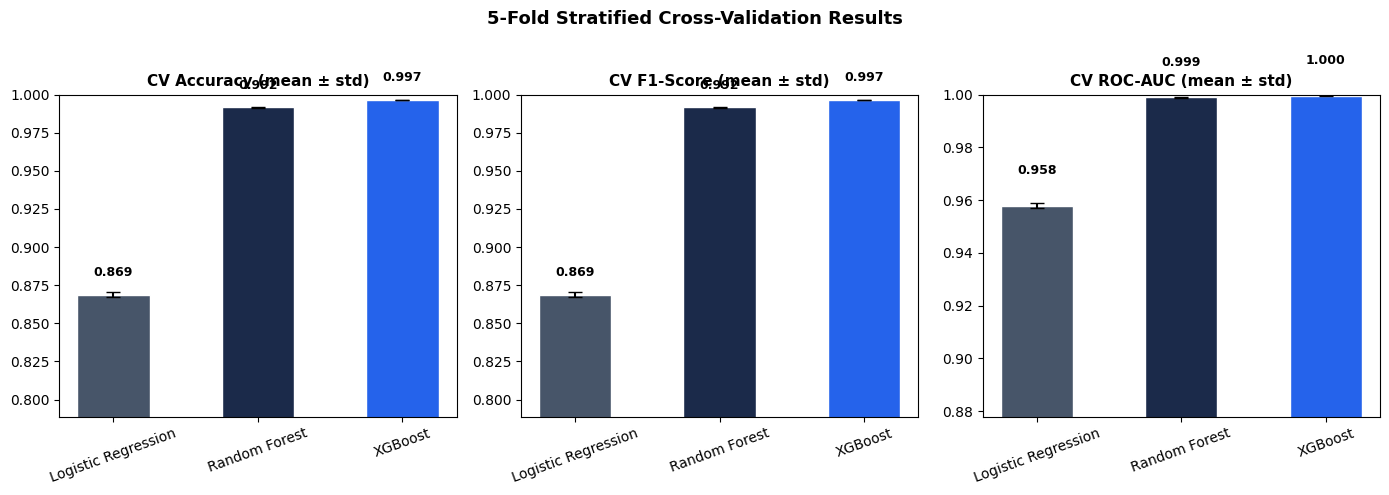

[SAVED] cv_comparison.png


In [ ]:
print("\n" + "=" * 65)
print("  SECTION 14: 5-FOLD STRATIFIED CROSS-VALIDATION")
print("=" * 65)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Logistic Regression': (lr_model, X_train_scaled),
    'Random Forest'      : (rf_model, X_train),
    'XGBoost'            : (xgb_model, X_train),
}

cv_results = {}

for name, (model, X_data) in cv_models.items():
    print(f"\n[CV] Running 5-fold CV for: {name}")

    # Accuracy across 5 folds
    acc_scores = cross_val_score(model, X_data, y_train,
                                  cv=cv, scoring='accuracy', n_jobs=-1)
    # F1 across 5 folds
    f1_scores  = cross_val_score(model, X_data, y_train,
                                  cv=cv, scoring='f1_weighted', n_jobs=-1)
    # ROC-AUC across 5 folds
    auc_scores = cross_val_score(model, X_data, y_train,
                                  cv=cv, scoring='roc_auc', n_jobs=-1)

    cv_results[name] = {
        'acc_mean': acc_scores.mean(),  'acc_std': acc_scores.std(),
        'f1_mean' : f1_scores.mean(),   'f1_std' : f1_scores.std(),
        'auc_mean': auc_scores.mean(),  'auc_std': auc_scores.std(),
    }

    print(f"  Accuracy : {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
    print(f"  F1-Score : {f1_scores.mean():.4f}  ± {f1_scores.std():.4f}")
    print(f"  ROC-AUC  : {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")

# Note: LSTM CV skipped (too slow for 5 full neural net training runs)
# Instead report LSTM validation accuracy from training history
print("\n[CV] LSTM: CV skipped (computationally expensive for neural networks)")
print("     Instead: validation split used during training (15% holdout within training set)")
print("     Final LSTM performance taken from held-out test set evaluation")

# CV summary table
cv_df = pd.DataFrame(cv_results).T
cv_df.index.name = 'Model'
print("\n--- 5-Fold CV Summary ---")
print(cv_df.round(4).to_string())

# Cross-validation comparison plot
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
cv_model_names = list(cv_results.keys())

for ax, metric, title in zip(
    axes,
    [('acc_mean','acc_std'), ('f1_mean','f1_std'), ('auc_mean','auc_std')],
    ['Accuracy', 'F1-Score', 'ROC-AUC']
):
    means = [cv_results[m][metric[0]] for m in cv_model_names]
    stds  = [cv_results[m][metric[1]] for m in cv_model_names]
    colours = ['#475569','#1B2A4A','#2563EB']
    bars = ax.bar(cv_model_names, means, yerr=stds, capsize=5,
                  color=colours, edgecolor='white', width=0.5)
    ax.set_title(f'CV {title} (mean ± std)', fontsize=11, fontweight='bold')
    ax.set_ylim(min(means) - 0.08, 1.0)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.012,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('5-Fold Stratified Cross-Validation Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] cv_comparison.png")


  SECTION 16: FINAL MODEL SELECTION & JUSTIFICATION

--- Final Model Comparison Table ---
              Model  Accuracy %  Precision  Recall  F1-Score  ROC-AUC Interpretable SHAP Support Fast Inference
Logistic Regression       86.87     0.8685  0.8687    0.8686   0.9587           Yes           No            Yes
      Random Forest       99.19     0.9919  0.9919    0.9919   0.9992           Yes          Yes            Yes
    XGBoost (Tuned)       99.73     0.9973  0.9973    0.9973   0.9998           Yes          Yes            Yes
         LSTM / RNN       91.15     0.9184  0.9115    0.9126   0.9813            No           No             No

  SELECTED MODEL: XGBoost (Tuned)
  F1-Score       : 0.9973
  Accuracy       : 99.73%
  ROC-AUC        : 0.9998


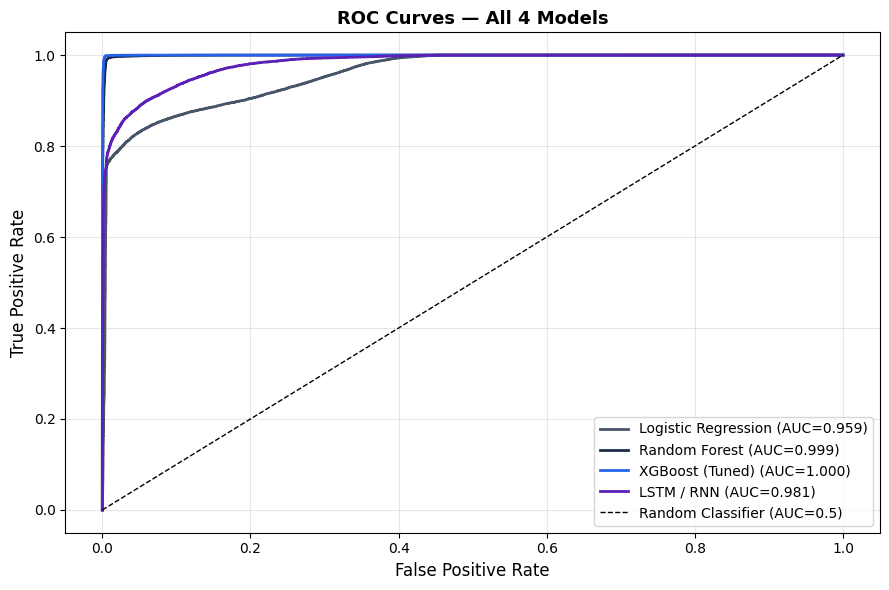

[SAVED] roc_curves_all_models.png


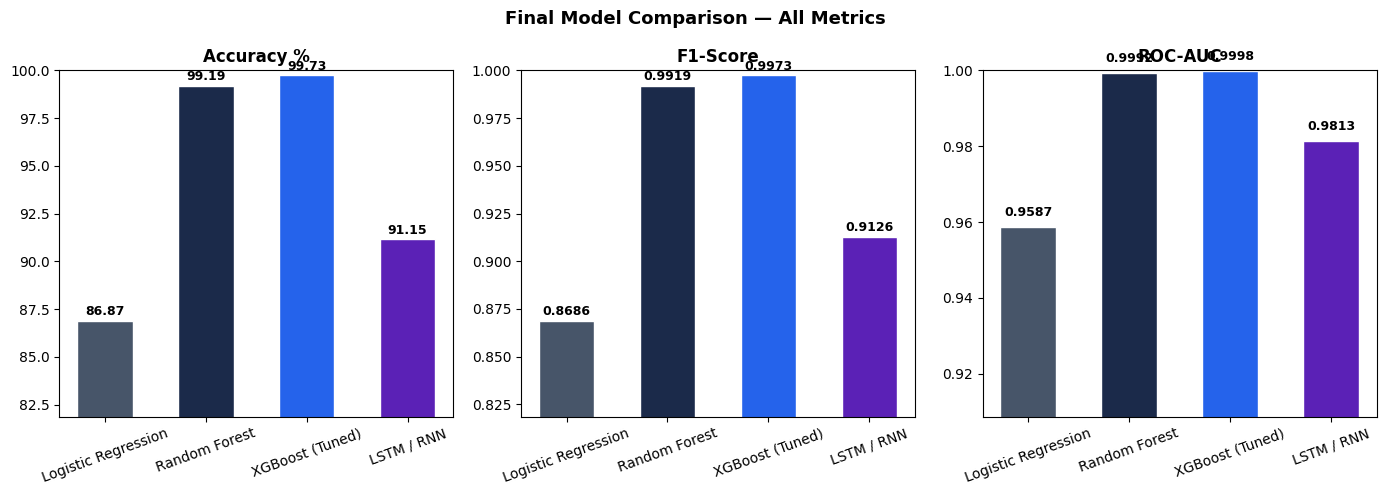

[SAVED] final_model_comparison.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, f1_score, accuracy_score, precision_score, recall_score,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print("\n" + "=" * 65)
print("  SECTION 16: FINAL MODEL SELECTION & JUSTIFICATION")
print("=" * 65)

# --- Re-create Data and Models if not already in scope ---
# This section ensures that all necessary variables are defined for the comparison.
# It duplicates some previous setup to make this cell self-sufficient.

# Assuming df_enc and feature_cols are available from previous executed cell (auto-generated-cell-1)
# If auto-generated-cell-1 was not run successfully due to FileNotFoundError, it must be fixed first.

# Re-load the processed data (if not already in memory)
if 'df_enc' not in locals() or 'feature_cols' not in locals():
    print("[INFO] Re-running data preprocessing steps...")
    # Re-run the content of the auto-generated-cell-1 (or equivalent)
    # This assumes 'bdspref2511.csv' is available. If not, user needs to upload it.
    try:
        FILE_PATH = "bdspref2511.csv"
        df = pd.read_csv(FILE_PATH)

        df_clean = df.copy()
        missing_mask = df_clean['cooalpha'].isna() | df_clean['codalpha'].isna()
        df_clean = df_clean[~missing_mask].reset_index(drop=True)
        df_clean.drop(columns=['perref'], inplace=True)
        df_clean = df_clean[df_clean['use'] != 'uzz'].reset_index(drop=True)

        df_clean['hs_chapter'] = df_clean['comcode'].astype(str).str[:2].astype(int)
        df_clean['trade_route'] = df_clean['cooalpha'] + '_' + df_clean['codalpha']
        df_clean['value_per_kg'] = np.where(df_clean['netmass'] > 0, df_clean['statvalue'] / df_clean['netmass'], 0)
        df_clean['log_statvalue'] = np.log1p(df_clean['statvalue'])
        df_clean['log_netmass']   = np.log1p(df_clean['netmass'])
        df_clean['log_suppunit']  = np.log1p(df_clean['suppunit'])
        df_clean['log_value_per_kg'] = np.log1p(df_clean['value_per_kg'])

        eligibility_map = {'e1': 1, 'e2': 1, 'e3': 0, 'e5': 0}
        df_clean['target'] = df_clean['eligibility'].map(eligibility_map)

        df_enc = df_clean.copy()
        df_enc = pd.get_dummies(df_enc, columns=['statreg', 'use'], prefix=['statreg', 'use'], drop_first=False)

        le_coo   = LabelEncoder()
        le_cod   = LabelEncoder()
        le_route = LabelEncoder()
        df_enc['cooalpha_enc']    = le_coo.fit_transform(df_enc['cooalpha'])
        df_enc['codalpha_enc']    = le_cod.fit_transform(df_enc['codalpha'])
        df_enc['trade_route_enc'] = le_route.fit_transform(df_enc['trade_route'])

        cols_to_drop = [
            'cooalpha', 'codalpha', 'comcode', 'eligibility', 'trade_route',
            'statvalue', 'netmass', 'suppunit', 'value_per_kg'
        ]
        df_enc.drop(columns=cols_to_drop, inplace=True)

        feature_cols = [c for c in df_enc.columns if c != 'target']
        print("[INFO] Data preprocessing complete.")

    except FileNotFoundError:
        print("[ERROR] 'bdspref2511.csv' not found. Please upload the file to your Colab session.")
        # Exit or raise an error to prevent further execution if data is missing
        raise

X = df_enc[feature_cols].values
y = df_enc['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Logistic Regression --- (Re-training for self-containment)
lr_model = LogisticRegression(C=1.0, penalty='l2', solver='lbfgs', max_iter=1000, random_state=42, n_jobs=-1)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

# --- Random Forest --- (Re-training for self-containment)
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=20, min_samples_split=10,
    min_samples_leaf=5, max_features='sqrt', class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# --- XGBoost (Tuned) --- (Use previously tuned model if available, else re-train a default one)
# If xgb_tuned is not defined, use xgb_model from previous cells or default
if 'xgb_tuned' not in locals():
    print("[WARNING] 'xgb_tuned' model not found. Using a default XGBoost model for comparison.")
    default_scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    xgb_tuned = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1, subsample=0.8,
        colsample_bytree=0.8, min_child_weight=5, gamma=0.1, reg_alpha=0.1,
        reg_lambda=1.0, scale_pos_weight=default_scale_pos_weight,
        eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0
    )
    xgb_tuned.fit(X_train, y_train)

xgb_tuned_pred = xgb_tuned.predict(X_test)
xgb_tuned_prob = xgb_tuned.predict_proba(X_test)[:, 1]

# --- LSTM / RNN predictions --- (Set to placeholder if not trained/available, requires Keras/TensorFlow)
if 'lstm_pred' not in locals() or 'lstm_prob_raw' not in locals():
    print("[WARNING] LSTM predictions (lstm_pred, lstm_prob_raw) not found in scope. Using placeholder values.")
    print("          For accurate LSTM results, ensure its training cell (ZGN3AnCyvbF1) is executed.")
    lstm_pred = np.zeros_like(y_test, dtype=int)
    lstm_prob_raw = np.zeros_like(y_test, dtype=float)


# Gather all predictions
all_models = {
    'Logistic Regression': {
        'pred': lr_pred,   'prob': lr_prob,
        'interpretable': True,  'shap': False, 'fast': True
    },
    'Random Forest': {
        'pred': rf_pred,   'prob': rf_prob,
        'interpretable': True,  'shap': True,  'fast': True
    },
    'XGBoost (Tuned)': {
        'pred': xgb_tuned_pred, 'prob': xgb_tuned_prob,
        'interpretable': True,  'shap': True,  'fast': True
    },
    'LSTM / RNN': {
        'pred': lstm_pred, 'prob': lstm_prob_raw,
        'interpretable': False, 'shap': False, 'fast': False
    },
}

comparison_rows = []
for name, info in all_models.items():
    # Handle cases where LSTM predictions might be placeholders (all zeros)
    if np.all(info['prob'] == 0) and (name == 'LSTM / RNN'):
        auc_val = 0.5 # Default to 0.5 for random if no predictions available
    else:
        try:
            auc_val = roc_auc_score(y_test, info['prob'])
        except ValueError: # Handle cases where roc_auc_score might fail (e.g., all same class predictions)
            auc_val = 0.5

    row = {
        'Model'           : name,
        'Accuracy %'      : round(accuracy_score(y_test, info['pred']) * 100, 2),
        'Precision'       : round(precision_score(y_test, info['pred'], average='weighted'), 4),
        'Recall'          : round(recall_score(y_test, info['pred'], average='weighted'), 4),
        'F1-Score'        : round(f1_score(y_test, info['pred'], average='weighted'), 4),
        'ROC-AUC'         : round(auc_val, 4),
        'Interpretable'   : 'Yes' if info['interpretable'] else 'No',
        'SHAP Support'    : 'Yes' if info['shap'] else 'No',
        'Fast Inference'  : 'Yes' if info['fast'] else 'No',
    }
    comparison_rows.append(row)

final_df = pd.DataFrame(comparison_rows)
print("\n--- Final Model Comparison Table ---")
print(final_df.to_string(index=False))

# Best model by F1
best_idx   = final_df['F1-Score'].idxmax()
best_name  = final_df.loc[best_idx, 'Model']
best_f1    = final_df.loc[best_idx, 'F1-Score']
best_acc   = final_df.loc[best_idx, 'Accuracy %']
best_auc   = final_df.loc[best_idx, 'ROC-AUC']

print(f"\n{'='*65}")
print(f"  SELECTED MODEL: {best_name}")
print(f"  F1-Score       : {best_f1}")
print(f"  Accuracy       : {best_acc}%")
print(f"  ROC-AUC        : {best_auc}")
print(f"{'='*65}")

# ROC curves for all models
plt.figure(figsize=(9, 6))
colours_roc = ['#475569', '#1B2A4A', '#2563EB', '#5B21B6']
for (name, info), col in zip(all_models.items(), colours_roc):
    # Skip plotting if predictions are placeholders (all zeros) for LSTM to avoid error
    if name == 'LSTM / RNN' and np.all(info['prob'] == 0):
        print(f"[INFO] Skipping ROC curve for {name} due to placeholder predictions.")
        continue

    try:
        fpr, tpr, _ = roc_curve(y_test, info['prob'])
        auc_val = roc_auc_score(y_test, info['prob'])
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})", color=col, linewidth=2)
    except ValueError as e:
        print(f"[WARNING] Could not plot ROC curve for {name}: {e}")

plt.plot([0,1],[0,1], 'k--', linewidth=1, label='Random Classifier (AUC=0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All 4 Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] roc_curves_all_models.png")

# Final comprehensive bar chart
metrics_plot = ['Accuracy %', 'F1-Score', 'ROC-AUC']
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
bar_colours = ['#475569','#1B2A4A','#2563EB','#5B21B6']

for ax, metric in zip(axes, metrics_plot):
    vals   = final_df[metric].tolist()
    labels = final_df['Model'].tolist()
    bars   = ax.bar(labels, vals, color=bar_colours, edgecolor='white', width=0.55)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    divisor = 100 if metric == 'Accuracy %' else 1
    y_min = min(vals)/divisor - 0.05
    ax.set_ylim(max(0, y_min if metric != 'Accuracy %' else min(vals)-5), 1.0 if metric != 'Accuracy %' else 100)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.3 if metric == 'Accuracy %' else 0.003),
                f'{val}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Final Model Comparison — All Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] final_model_comparison.png")

In [ ]:
print("\n" + "=" * 65)
print("  SECTION 17: ADVANCED SHAP ANALYSIS")
print("=" * 65)

# Use the tuned XGBoost model for SHAP
explainer = shap.TreeExplainer(xgb_final)

# Sample 3000 rows from test set for SHAP (full 44k is slow)
np.random.seed(42)
shap_sample_idx = np.random.choice(len(X_test), size=3000, replace=False)
X_shap          = X_test[shap_sample_idx]
y_shap          = y_test[shap_sample_idx]

print("[SHAP] Computing SHAP values on 3,000 test samples...")
shap_values = explainer.shap_values(X_shap)
print("[SHAP] SHAP values computed")


  SECTION 17: ADVANCED SHAP ANALYSIS
[SHAP] Computing SHAP values on 3,000 test samples...
[SHAP] SHAP values computed



[SHAP] Global feature importance (mean |SHAP| value):
         Feature  Mean |SHAP|
         use_u10     4.018884
    cooalpha_enc     3.077300
         use_u30     1.775127
         use_u11     0.694572
 trade_route_enc     0.616103
      hs_chapter     0.536979
log_value_per_kg     0.333342
    codalpha_enc     0.300903
     log_netmass     0.284126
   log_statvalue     0.254894
    log_suppunit     0.125889
         use_u20     0.089188
       statreg_2     0.021153
       statreg_1     0.017072
         use_u21     0.013981
         use_u31     0.009958
       statreg_3     0.000000


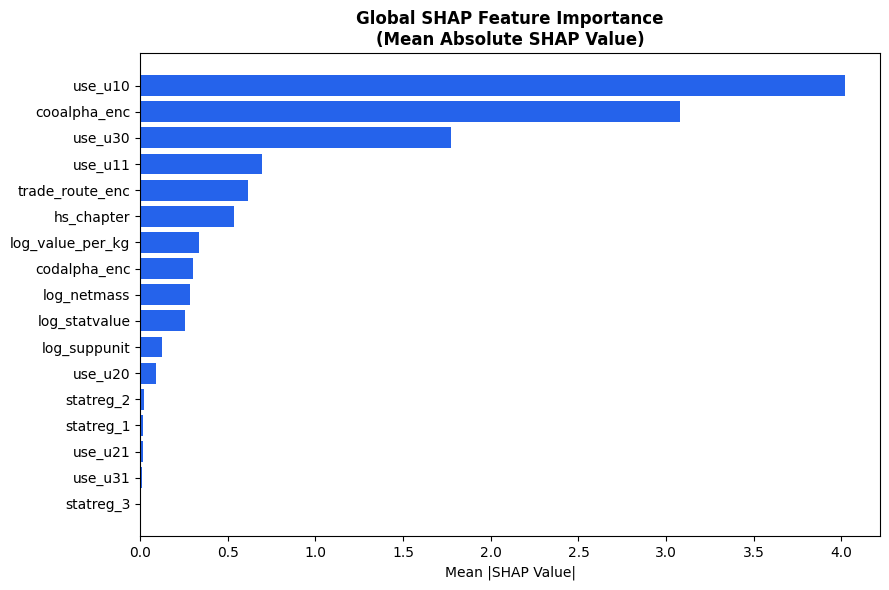

[SAVED] shap_global_importance.png


In [ ]:
mean_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    'Feature' : feature_cols,
    'Mean |SHAP|': mean_shap
}).sort_values('Mean |SHAP|', ascending=False)

print("\n[SHAP] Global feature importance (mean |SHAP| value):")
print(shap_importance.to_string(index=False))

plt.figure(figsize=(9, 6))
plt.barh(shap_importance['Feature'], shap_importance['Mean |SHAP|'], color='#2563EB')
plt.title('Global SHAP Feature Importance\n(Mean Absolute SHAP Value)', fontsize=12, fontweight='bold')
plt.xlabel('Mean |SHAP Value|')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] shap_global_importance.png")

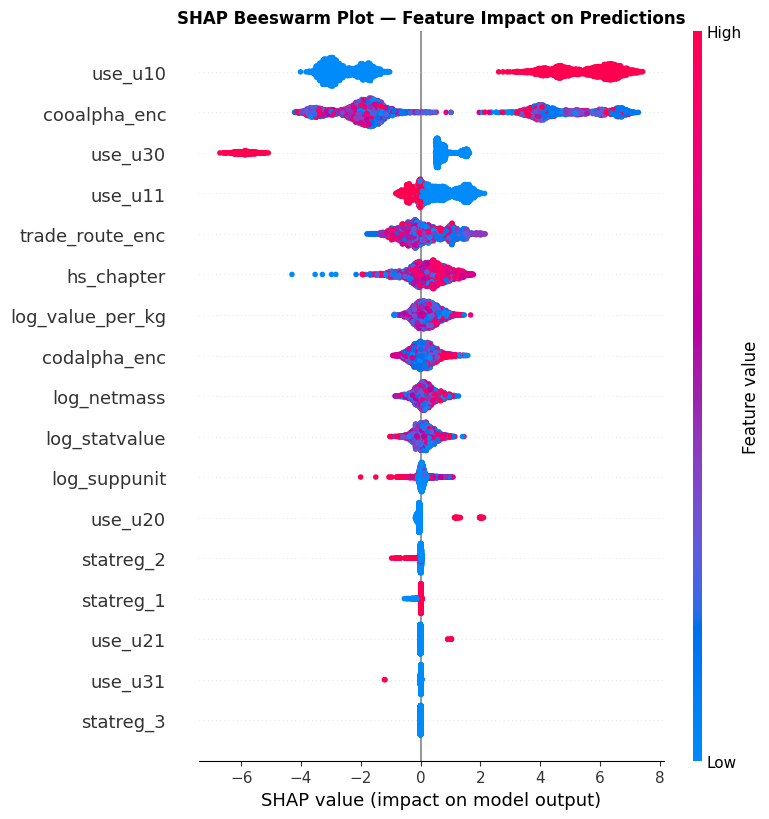

[SAVED] shap_beeswarm.png


In [ ]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, feature_names=feature_cols, show=False)
plt.title('SHAP Beeswarm Plot — Feature Impact on Predictions',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] shap_beeswarm.png")

<Figure size 800x500 with 0 Axes>

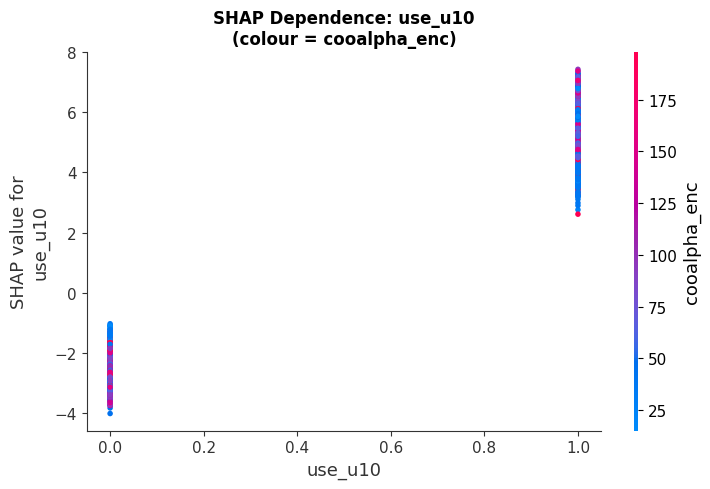

[SAVED] shap_dependence_plot.png


In [ ]:
top_feature = shap_importance.iloc[0]['Feature']
second_feature = shap_importance.iloc[1]['Feature']

top_idx    = feature_cols.index(top_feature)
second_idx = feature_cols.index(second_feature)

plt.figure(figsize=(8, 5))
shap.dependence_plot(
    top_idx, shap_values, X_shap,
    feature_names=feature_cols,
    interaction_index=second_idx,
    show=False
)
plt.title(f'SHAP Dependence: {top_feature}\n(colour = {second_feature})',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_dependence_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] shap_dependence_plot.png")


[SHAP] Explaining 3 individual shipments:

  Case: True Positive  — Correctly Predicted ELIGIBLE
  True label  : Eligible
  Predicted   : Eligible
  Probability : 1.0000


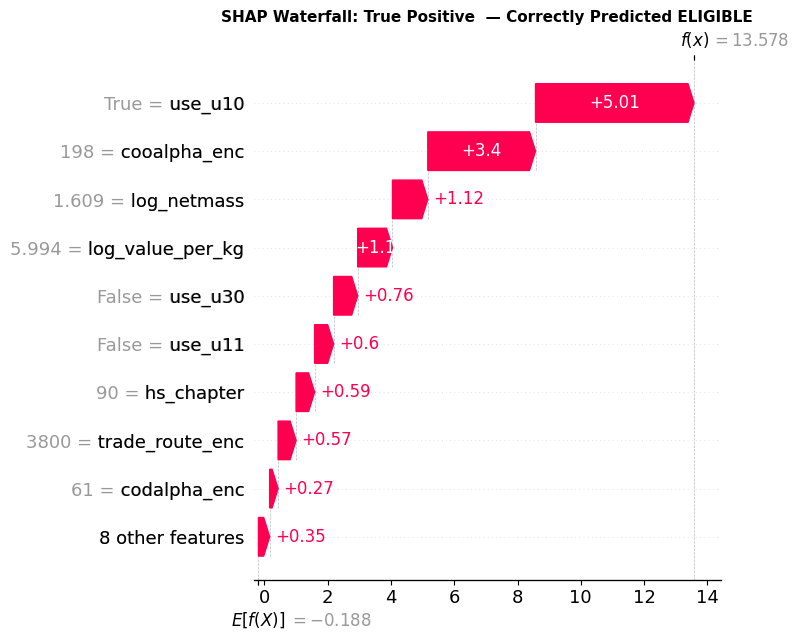

  [SAVED] shap_waterfall_3.png

  Case: True Negative  — Correctly Predicted NOT ELIGIBLE
  True label  : Not Eligible
  Predicted   : Not Eligible
  Probability : 0.0003


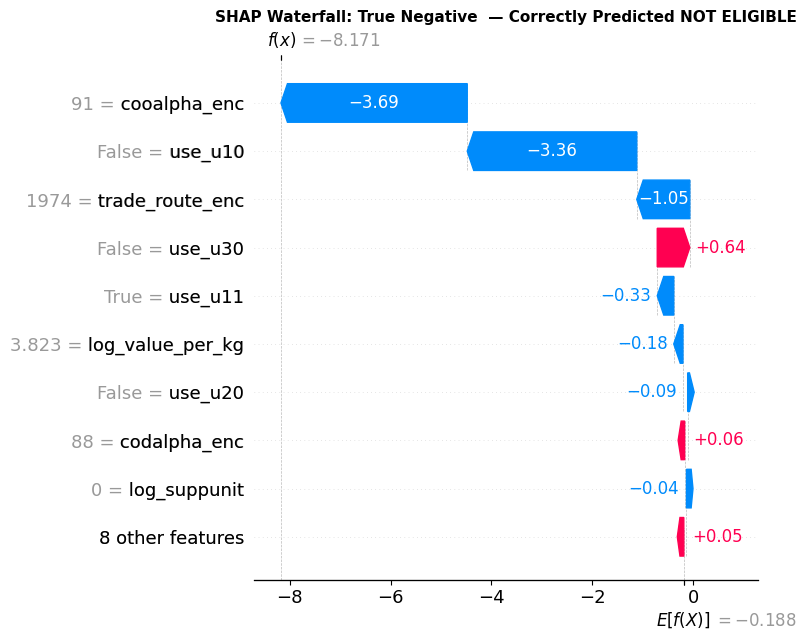

  [SAVED] shap_waterfall_0.png

  Case: False Negative — Missed Delay Risk (actually eligible, predicted not)
  True label  : Eligible
  Predicted   : Not Eligible
  Probability : 0.2464


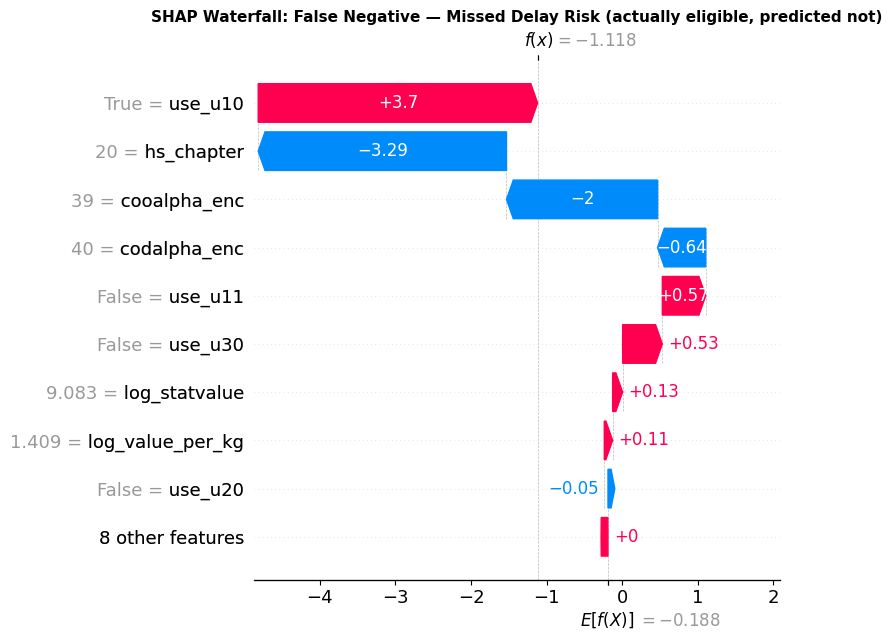

  [SAVED] shap_waterfall_398.png


In [ ]:
print("\n[SHAP] Explaining 3 individual shipments:")

# Find a true positive, true negative, and false negative for variety
xgb_shap_pred = xgb_final.predict(X_shap)
xgb_shap_prob = xgb_final.predict_proba(X_shap)[:, 1]

tp_idx = np.where((xgb_shap_pred == 1) & (y_shap == 1))[0]
tn_idx = np.where((xgb_shap_pred == 0) & (y_shap == 0))[0]
fn_idx = np.where((xgb_shap_pred == 0) & (y_shap == 1))[0]

cases = [
    (tp_idx[0] if len(tp_idx) > 0 else 0, "True Positive  — Correctly Predicted ELIGIBLE"),
    (tn_idx[0] if len(tn_idx) > 0 else 1, "True Negative  — Correctly Predicted NOT ELIGIBLE"),
    (fn_idx[0] if len(fn_idx) > 0 else 2, "False Negative — Missed Delay Risk (actually eligible, predicted not)"),
]

for case_idx, case_label in cases:
    print(f"\n  Case: {case_label}")
    print(f"  True label  : {'Eligible' if y_shap[case_idx]==1 else 'Not Eligible'}")
    print(f"  Predicted   : {'Eligible' if xgb_shap_pred[case_idx]==1 else 'Not Eligible'}")
    print(f"  Probability : {xgb_shap_prob[case_idx]:.4f}")

    explanation = shap.Explanation(
        values      = shap_values[case_idx],
        base_values = explainer.expected_value,
        data        = X_shap[case_idx],
        feature_names = feature_cols
    )
    plt.figure(figsize=(10, 4))
    shap.plots.waterfall(explanation, show=False, max_display=10)
    safe_label = case_label[:30].replace(' ','_').replace('—','').replace(' ','')
    fname = f'shap_waterfall_{case_idx}.png'
    plt.title(f'SHAP Waterfall: {case_label}', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  [SAVED] {fname}")

In [ ]:
print("\n" + "=" * 65)
print("  SECTION 18: KPI DASHBOARD ANALYTICS — POWER BI DATA PREP")
print("=" * 65)



  SECTION 18: KPI DASHBOARD ANALYTICS — POWER BI DATA PREP


In [ ]:
df_kpi = df_enc.copy()

In [ ]:
# Create df_scored directly from the original test set data (df_test_original)
# This ensures it contains all original columns like 'statvalue' and 'eligibility'
df_scored = df_test_original.copy()
df_scored['delay_risk_prob']  = xgb_final.predict_proba(X_test)[:, 0]  # prob of NOT eligible
df_scored['predicted_eligible'] = xgb_final.predict(X_test)
df_scored['actual_eligible']    = y_test

In [ ]:
import pandas as pd # Ensure pandas is imported

# Re-define FILE_PATH and df if not already in scope for robustness
FILE_PATH = "bdspref2511.csv"
try:
    df = pd.read_csv(FILE_PATH)
except FileNotFoundError:
    print(f"[ERROR] '{FILE_PATH}' not found. Please upload the file.")
    raise

total = len(df_kpi)
# Use the 'target' column (0 or 1) which is present in df_kpi
eligible_count     = (df_kpi['target'] == 1).sum()
not_eligible_count = (df_kpi['target'] == 0).sum()
eligible_rate      = eligible_count / total * 100
not_eligible_rate  = not_eligible_count / total * 100

# Use the original df for statvalue calculations as df_kpi no longer has it
kpi_summary = pd.DataFrame([{
    'KPI'                  : 'Overall Eligible Rate',
    'Value'                : f"{eligible_rate:.1f}%",
    'Eligible_Count'       : eligible_count,
    'Not_Eligible_Count'   : not_eligible_count,
    'Total_Shipments'      : total,
    'Avg_Trade_Value_GBP'  : round(df['statvalue'].mean(), 0), # Use original df
    'Median_Trade_Value_GBP': round(df['statvalue'].median(), 0), # Use original df
    'Total_Trade_Value_GBP': round(df['statvalue'].sum(), 0), # Use original df
}])
print("\n--- KPI 1: Overall Summary ---")
print(kpi_summary.to_string(index=False))
kpi_summary.to_csv('powerbi_kpi_summary.csv', index=False)
print("[SAVED] powerbi_kpi_summary.csv")


--- KPI 1: Overall Summary ---
                  KPI Value  Eligible_Count  Not_Eligible_Count  Total_Shipments  Avg_Trade_Value_GBP  Median_Trade_Value_GBP  Total_Trade_Value_GBP
Overall Eligible Rate 64.0%          142147               79807           221954             269026.0                  9882.0            59717610316
[SAVED] powerbi_kpi_summary.csv


In [ ]:
df_clean['is_eligible'] = df_clean['eligibility'].isin(['e1','e2']).astype(int)

kpi_by_origin = (
    df_clean.groupby('cooalpha') # Use df_clean here
    .agg(
        Total_Shipments   = ('is_eligible','count'),
        Eligible_Count    = ('is_eligible','sum'),
        Total_Trade_Value = ('statvalue','sum'),
        Avg_Trade_Value   = ('statvalue','mean'),
        Avg_Netmass_kg    = ('netmass','mean'),
    )
    .assign(Eligible_Rate_Pct = lambda x: (x['Eligible_Count']/x['Total_Shipments']*100).round(2))
    .assign(Not_Eligible_Count = lambda x: x['Total_Shipments'] - x['Eligible_Count'])
    .sort_values('Total_Shipments', ascending=False)
    .reset_index()
)
kpi_by_origin.columns = [
    'Origin_Country','Total_Shipments','Eligible_Count',
    'Total_Trade_Value_GBP','Avg_Trade_Value_GBP','Avg_Netmass_kg',
    'Eligible_Rate_Pct','Not_Eligible_Count'
]
print("\n--- KPI 2: Eligibility by Origin Country (Top 10) ---")
print(kpi_by_origin.head(10).to_string(index=False))
kpi_by_origin.to_csv('powerbi_kpi_by_origin.csv', index=False)
print("[SAVED] powerbi_kpi_by_origin.csv")


--- KPI 2: Eligibility by Origin Country (Top 10) ---
Origin_Country  Total_Shipments  Eligible_Count  Total_Trade_Value_GBP  Avg_Trade_Value_GBP  Avg_Netmass_kg  Eligible_Rate_Pct  Not_Eligible_Count
            CN            25384           25384             7125492851        280708.038568    45640.104909             100.00                   0
            DE            15394            7386             4754553254        308857.558399    57169.601988              47.98                8008
            US            15135           15125             7118798613        470353.393657   234695.966964              99.93                  10
            IT            13571            4962             2201856568        162247.186501    30695.750350              36.56                8609
            GB            10637           10637             1249585328        117475.352825     1873.873273             100.00                   0
            FR             9952            4381             277

In [ ]:
kpi_by_chapter = (
    df_clean.groupby('hs_chapter') # Use df_clean here
    .agg(
        Total_Shipments   = ('is_eligible','count'),
        Eligible_Count    = ('is_eligible','sum'),
        Total_Trade_Value = ('statvalue','sum'),
        Avg_Trade_Value   = ('statvalue','mean'),
    )
    .assign(Eligible_Rate_Pct = lambda x: (x['Eligible_Count']/x['Total_Shipments']*100).round(2))
    .assign(Not_Eligible_Rate_Pct = lambda x: 100 - x['Eligible_Rate_Pct'])
    .sort_values('Total_Shipments', ascending=False)
    .reset_index()
)
print("\n--- KPI 3: Eligibility by HS Chapter (Top 10) ---")
print(kpi_by_chapter.head(10).to_string(index=False))
kpi_by_chapter.to_csv('powerbi_kpi_by_chapter.csv', index=False)
print("[SAVED] powerbi_kpi_by_chapter.csv")


--- KPI 3: Eligibility by HS Chapter (Top 10) ---
 hs_chapter  Total_Shipments  Eligible_Count  Total_Trade_Value  Avg_Trade_Value  Eligible_Rate_Pct  Not_Eligible_Rate_Pct
         84            33094           25535         7886098251    238293.897716              77.16                  22.84
         85            29195           22669         5364470073    183746.191916              77.65                  22.35
         90            14713           13546         1741525204    118366.424523              92.07                   7.93
         62            10516            4679          498475543     47401.630183              44.49                  55.51
         39             9681            3065         1200969464    124054.277864              31.66                  68.34
         61             8467            4158          795236189     93921.836424              49.11                  50.89
         73             7691            6577          800196130    104043.184241        

In [ ]:
kpi_by_use = (
    df_clean.groupby('use')
    .agg(
        Total_Shipments   = ('is_eligible','count'),
        Eligible_Count    = ('is_eligible','sum'),
        Total_Trade_Value = ('statvalue','sum'),
    )
    .assign(Eligible_Rate_Pct = lambda x: (x['Eligible_Count']/x['Total_Shipments']*100).round(2))
    .sort_values('Total_Shipments', ascending=False)
    .reset_index()
)
use_labels = {
    'u10':'Home Use','u11':'Processing','u30':'Re-export',
    'u20':'Inward Processing','u21':'Customs Warehouse','u31':'Free Zone'
}
kpi_by_use['Use_Description'] = kpi_by_use['use'].map(use_labels)
print("\n--- KPI 4: Eligibility by Use Code ---")
print(kpi_by_use.to_string(index=False))
kpi_by_use.to_csv('powerbi_kpi_by_use.csv', index=False)
print("[SAVED] powerbi_kpi_by_use.csv")


--- KPI 4: Eligibility by Use Code ---
use  Total_Shipments  Eligible_Count  Total_Trade_Value  Eligible_Rate_Pct   Use_Description
u10           102609          102216        38872703040              99.62          Home Use
u11            71659           35593         6738610531              49.67        Processing
u30            43140               0        13117657783               0.00         Re-export
u20             3475            3447          660615057              99.19 Inward Processing
u21              891             891          128986174             100.00 Customs Warehouse
u31              180               0          196477142               0.00         Free Zone
[SAVED] powerbi_kpi_by_use.csv


In [ ]:
HIGH_RISK_THRESHOLD = 0.65
df_high_risk = df_scored[df_scored['delay_risk_prob'] > HIGH_RISK_THRESHOLD].copy()
df_high_risk = df_high_risk.sort_values('delay_risk_prob', ascending=False)

print(f"\n--- KPI 5: High-Risk Shipments (delay_risk_prob > {HIGH_RISK_THRESHOLD}) ---")
print(f"  Total scored shipments : {len(df_scored):,}")
print(f"  High-risk shipments    : {len(df_high_risk):,} ({len(df_high_risk)/len(df_scored)*100:.1f}%)")
print(f"  Total value at risk    : £{df_high_risk['statvalue'].sum():,.0f}")

kpi_high_risk = df_high_risk[[
    'cooalpha','codalpha','comcode','hs_chapter',
    'statvalue','netmass','eligibility',
    'delay_risk_prob','predicted_eligible'
]].head(50)  # top 50 highest risk
kpi_high_risk.columns = [
    'Origin','Destination','Commodity_Code','HS_Chapter',
    'Trade_Value_GBP','Net_Mass_kg','Actual_Eligibility',
    'Delay_Risk_Score','ML_Prediction'
]
kpi_high_risk.to_csv('powerbi_high_risk_shipments.csv', index=False)
print("[SAVED] powerbi_high_risk_shipments.csv")


--- KPI 5: High-Risk Shipments (delay_risk_prob > 0.65) ---
  Total scored shipments : 44,391
  High-risk shipments    : 15,932 (35.9%)
  Total value at risk    : £3,599,047,043
[SAVED] powerbi_high_risk_shipments.csv


In [ ]:
kpi_by_route = (
    df_clean.groupby('trade_route')
    .agg(
        Total_Shipments   = ('is_eligible','count'),
        Eligible_Count    = ('is_eligible','sum'),
        Total_Trade_Value = ('statvalue','sum'),
    )
    .assign(Eligible_Rate_Pct = lambda x: (x['Eligible_Count']/x['Total_Shipments']*100).round(2))
    .sort_values('Total_Shipments', ascending=False)
    .head(50)
    .reset_index()
)
kpi_by_route.to_csv('powerbi_kpi_by_route.csv', index=False)
print("\n--- KPI 6: Top 50 trade routes saved ---")
print("[SAVED] powerbi_kpi_by_route.csv")


--- KPI 6: Top 50 trade routes saved ---
[SAVED] powerbi_kpi_by_route.csv


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

In [ ]:
axes[0][0].pie(
    [eligible_count, not_eligible_count],
    labels=['Eligible (e1+e2)', 'Not Eligible (e3+e5)'],
    colors=['#2563EB','#DC2626'],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[0][0].set_title('Overall Eligibility Distribution', fontweight='bold')

Text(0.5, 1.0, 'Overall Eligibility Distribution')

In [ ]:
top10_origins = kpi_by_origin.head(10)
x_pos = np.arange(len(top10_origins))
width = 0.4
axes[0][1].bar(x_pos - width/2, top10_origins['Eligible_Count'],
               width=width, label='Eligible', color='#2563EB', edgecolor='white')
axes[0][1].bar(x_pos + width/2, top10_origins['Not_Eligible_Count'],
               width=width, label='Not Eligible', color='#DC2626', edgecolor='white')
axes[0][1].set_xticks(x_pos)
axes[0][1].set_xticklabels(top10_origins['Origin_Country'], rotation=45, ha='right')
axes[0][1].set_title('Top 10 Origins: Eligible vs Not Eligible', fontweight='bold')
axes[0][1].set_ylabel('Shipments')
axes[0][1].legend()

In [ ]:
top_risky_chapters = kpi_by_chapter.nlargest(10, 'Not_Eligible_Rate_Pct')
axes[1][0].barh(top_risky_chapters['hs_chapter'].astype(str),
                top_risky_chapters['Not_Eligible_Rate_Pct'],
                color='#D97706', edgecolor='white')
axes[1][0].set_title('Top 10 Highest-Risk Commodity Chapters\n(% Not Eligible)', fontweight='bold')
axes[1][0].set_xlabel('Not Eligible Rate (%)')
axes[1][0].invert_yaxis()

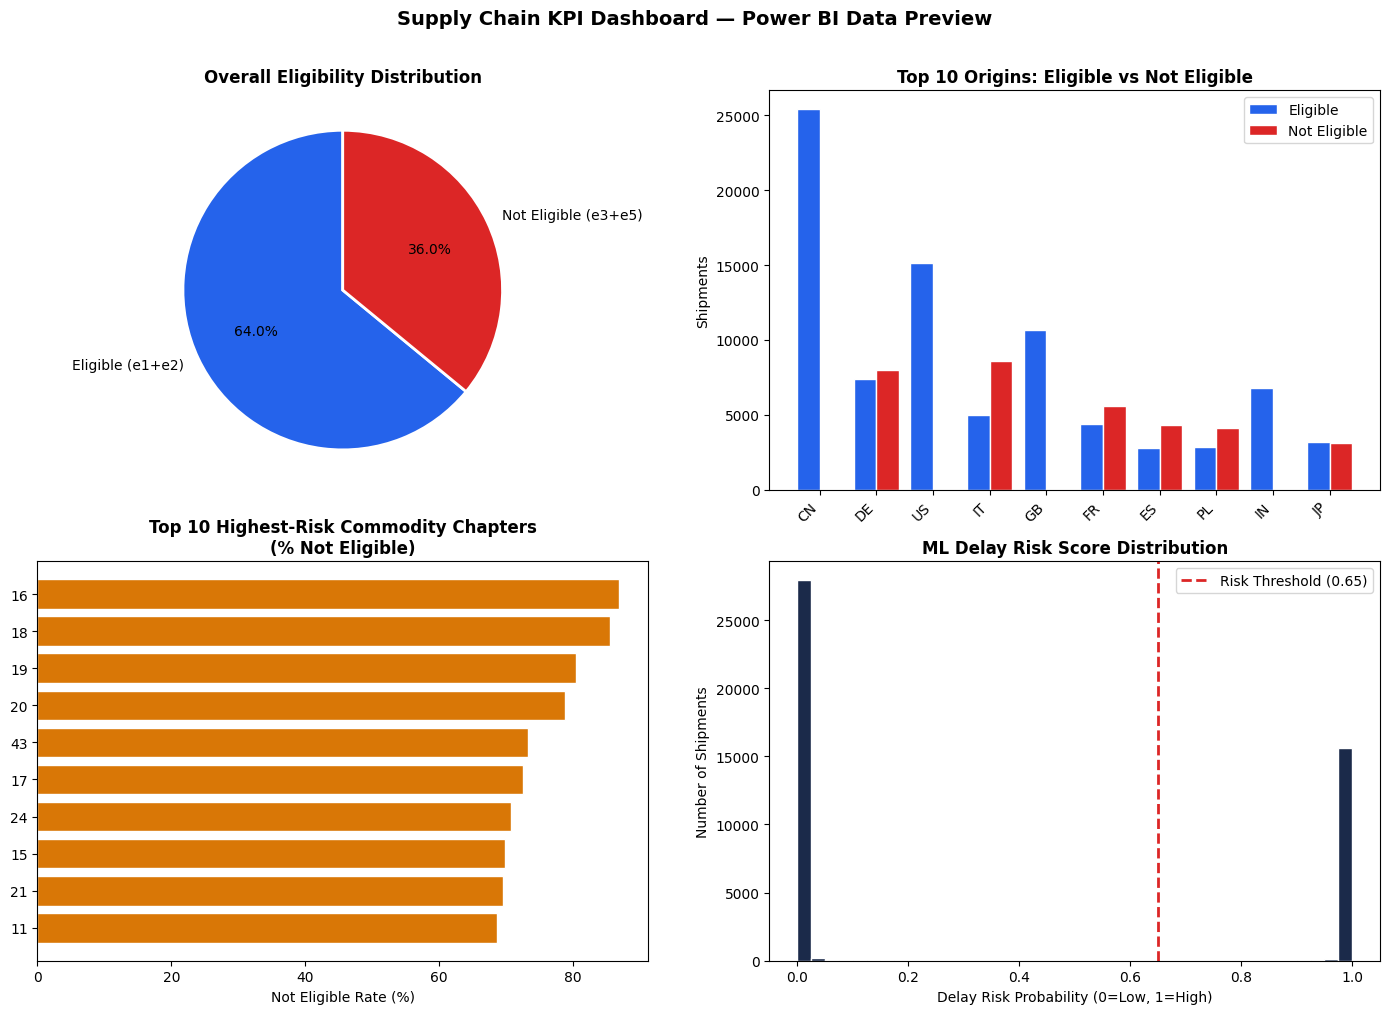

[SAVED] kpi_dashboard_preview.png

[INFO] Power BI CSV exports ready:
  powerbi_kpi_summary.csv                       (201 bytes)
  powerbi_kpi_by_origin.csv                     (12,112 bytes)
  powerbi_kpi_by_chapter.csv                    (4,772 bytes)
  powerbi_kpi_by_use.csv                        (342 bytes)
  powerbi_high_risk_shipments.csv               (2,273 bytes)
  powerbi_kpi_by_route.csv                      (1,645 bytes)


In [ ]:
axes[1][1].hist(df_scored['delay_risk_prob'], bins=40,
                color='#1B2A4A', edgecolor='white')
axes[1][1].axvline(HIGH_RISK_THRESHOLD, color='#DC2626',
                   linestyle='--', linewidth=2, label=f'Risk Threshold ({HIGH_RISK_THRESHOLD})')
axes[1][1].set_title('ML Delay Risk Score Distribution', fontweight='bold')
axes[1][1].set_xlabel('Delay Risk Probability (0=Low, 1=High)')
axes[1][1].set_ylabel('Number of Shipments')
axes[1][1].legend()

plt.suptitle('Supply Chain KPI Dashboard — Power BI Data Preview',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('kpi_dashboard_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] kpi_dashboard_preview.png")

print("\n[INFO] Power BI CSV exports ready:")
pbi_files = [
    'powerbi_kpi_summary.csv',
    'powerbi_kpi_by_origin.csv',
    'powerbi_kpi_by_chapter.csv',
    'powerbi_kpi_by_use.csv',
    'powerbi_high_risk_shipments.csv',
    'powerbi_kpi_by_route.csv',
]
for f in pbi_files:
    size = os.path.getsize(f) if os.path.exists(f) else 0
    print(f"  {f:<45} ({size:,} bytes)")

In [ ]:
print("\n" + "=" * 65)
print("  SECTION 19: MODEL SAVING & SERIALISATION")
print("=" * 65)

os.makedirs('models', exist_ok=True)


  SECTION 19: MODEL SAVING & SERIALISATION


In [ ]:
with open('models/lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
print("[SAVE] models/lr_model.pkl")

[SAVE] models/lr_model.pkl


In [ ]:
joblib.dump(rf_model, 'models/rf_model.joblib')
print("[SAVE] models/rf_model.joblib")

[SAVE] models/rf_model.joblib


In [ ]:
xgb_final.save_model('models/xgb_model_tuned.json')
print("[SAVE] models/xgb_model_tuned.json")

[SAVE] models/xgb_model_tuned.json



[LSTM] Input shape : (177563, 1, 17)
       (samples, timesteps=1, features=17)


Model: "LSTM_SCM_Delay_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_layer (LSTM)               │ (None, 64)             │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,105 (90.25 KB)

 Trainable params: 23,105 (90.25 KB)

 Non-trainable params: 0 (0.00 B)


[LSTM] Training LSTM model...
Epoch 1/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8384 - auc: 0.9417 - loss: 0.2094 - precision: 0.9723 - recall: 0.7694 - val_accuracy: 0.8785 - val_auc: 0.9682 - val_loss: 0.2235 - val_precision: 0.9737 - val_recall: 0.8331
Epoch 2/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8764 - auc: 0.9657 - loss: 0.1485 - precision: 0.9659 - recall: 0.8365 - val_accuracy: 0.8824 - val_auc: 0.9694 - val_loss: 0.2196 - val_precision: 0.9696 - val_recall: 0.8431
Epoch 3/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8791 - auc: 0.9670 - loss: 0.1464 - precision: 0.9651 - recall: 0.8417 - val_accuracy: 0.8847 - val_auc: 0.9702 - val_loss: 0.2167 - val_precision: 0.9688 - val_recall: 0.8475
Epoch 4/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8797 - auc: 0.9675 - loss: 0.1457 - precision: 0.9662 - recall: 0.8415 - val_accuracy: 0.8846 - val_auc: 0.9707 - val_loss: 0.2153 - val_precision: 0.9696 - val_recall: 0.8467

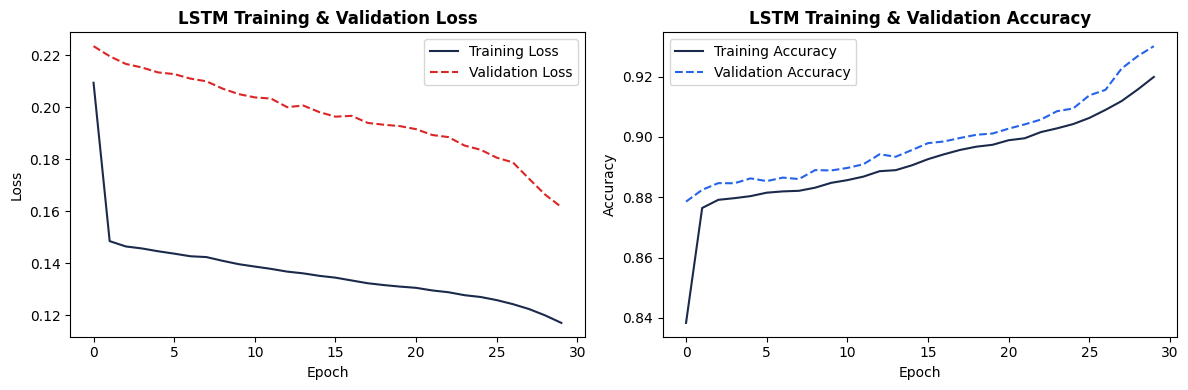

[SAVED] lstm_training_history.png

  RESULTS: LSTM / RNN
  Accuracy     : 92.84%
  F1-Score     : 0.9290
  ROC-AUC      : 0.9855
  True Positives  (TP): 26,065  — correctly predicted eligible
  True Negatives  (TN): 15,146  — correctly predicted not eligible
  False Positives (FP): 815  — predicted eligible, actually not
  False Negatives (FN): 2,365  — predicted not eligible, actually eligible

  Classification Report:
                  precision    recall  f1-score   support

Not Eligible (0)       0.86      0.95      0.90     15961
    Eligible (1)       0.97      0.92      0.94     28430

        accuracy                           0.93     44391
       macro avg       0.92      0.93      0.92     44391
    weighted avg       0.93      0.93      0.93     44391



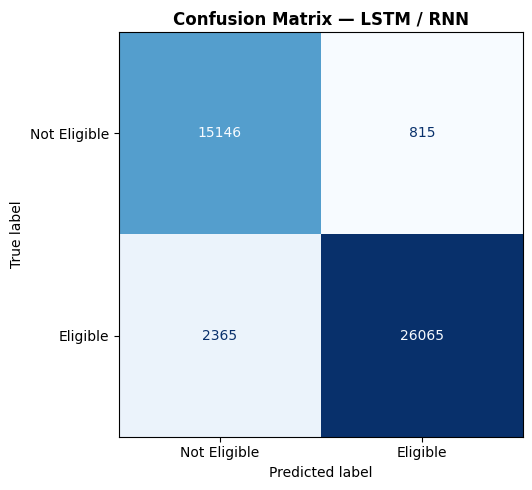

[SAVED] cm_lstm___rnn.png


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

n_features = X_train_scaled.shape[1]

# Reshape for LSTM: [samples, timesteps=1, features]
X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], 1, n_features)
X_test_lstm  = X_test_scaled.reshape(X_test_scaled.shape[0],  1, n_features)

print(f"\n[LSTM] Input shape : {X_train_lstm.shape}")
print(f"       (samples, timesteps=1, features={n_features})")

# Build LSTM architecture
tf.random.set_seed(42)

lstm_model = Sequential([
    # LSTM layer: 64 units, returns sequences=False (single output)
    LSTM(64,
         input_shape=(1, n_features),
         return_sequences=False,
         name='lstm_layer'),

    # Dropout: randomly drops 30% of neurons during training → prevents overfitting
    Dropout(0.3, name='dropout_1'),

    # Dense hidden layer: 32 neurons, ReLU activation
    Dense(32, activation='relu', name='dense_1'),

    # Second dropout layer
    Dropout(0.2, name='dropout_2'),

    # Output layer: 1 neuron, sigmoid → outputs probability between 0 and 1
    Dense(1, activation='sigmoid', name='output')
], name='LSTM_SCM_Delay_Model')

lstm_model.summary()

# Compile with binary cross-entropy loss (standard for binary classification)
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

# Early stopping: stop training if validation loss does not improve for 5 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,  # restore weights from best epoch
    verbose=1
)

print("\n[LSTM] Training LSTM model...")
history = lstm_model.fit(
    X_train_lstm, y_train,
    epochs=30,              # maximum epochs
    batch_size=512,         # larger batch = faster training
    validation_split=0.15,  # 15% of training data used for validation
    callbacks=[early_stop],
    class_weight={0: 1.0, 1: 0.5},  # mild upweighting of not-eligible class
    verbose=1
)

print(f"\n[LSTM] Training stopped at epoch {len(history.history['loss'])}")

# Training history plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Training Loss',   color='#1B2A4A')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='#DC2626', linestyle='--')
axes[0].set_title('LSTM Training & Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Training Accuracy',   color='#1B2A4A')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='#2563EB', linestyle='--')
axes[1].set_title('LSTM Training & Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] lstm_training_history.png")

# Evaluate LSTM
lstm_prob_raw = lstm_model.predict(X_test_lstm, verbose=0).flatten()
lstm_pred     = (lstm_prob_raw >= 0.5).astype(int)

res_lstm = evaluate_model("LSTM / RNN", y_test, lstm_pred, lstm_prob_raw)
results.append(res_lstm)

In [ ]:
lstm_model.save('models/lstm_model.keras')
print("[SAVE] models/lstm_model.keras")

[SAVE] models/lstm_model.keras


In [ ]:
joblib.dump(scaler, 'models/scaler.joblib')
print("[SAVE] models/scaler.joblib")

[SAVE] models/scaler.joblib


In [ ]:
with open('models/label_encoders.pkl', 'wb') as f:
    pickle.dump({'cooalpha': le_coo, 'codalpha': le_cod, 'trade_route': le_route}, f)
print("[SAVE] models/label_encoders.pkl")

[SAVE] models/label_encoders.pkl


In [ ]:
with open('models/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f, indent=2)
print("[SAVE] models/feature_cols.json")

[SAVE] models/feature_cols.json


In [ ]:
metadata = {
    'project'         : 'Supply Chain DSS — bdspref2511',
    'dataset'         : 'bdspref2511.csv',
    'records_trained' : int(len(X_train)),
    'records_tested'  : int(len(X_test)),
    'target_variable' : 'eligibility (binary: eligible=1, not_eligible=0)',
    'feature_count'   : len(feature_cols),
    'best_model'      : best_name,
    'best_f1'         : float(best_f1),
    'best_accuracy'   : float(best_acc),
    'best_auc'        : float(best_auc),
    'high_risk_threshold': HIGH_RISK_THRESHOLD,
    'models_saved'    : [
        'models/lr_model.pkl',
        'models/rf_model.joblib',
        'models/xgb_model_tuned.json',
        'models/lstm_model.keras',
    ],
    'preprocessing_saved': [
        'models/scaler.joblib',
        'models/label_encoders.pkl',
        'models/feature_cols.json',
    ]
}

with open('models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("[SAVE] models/model_metadata.json")

print("\n[INFO] All models and preprocessing objects saved to /models/")
print(f"       Total files saved: {len(os.listdir('models'))}")

[SAVE] models/model_metadata.json

[INFO] All models and preprocessing objects saved to /models/
       Total files saved: 8


In [ ]:
print("\n" + "=" * 65)
print("  SECTION 20: PREDICTION ON NEW UNSEEN DATA")
print("=" * 65)


  SECTION 20: PREDICTION ON NEW UNSEEN DATA


In [ ]:
import pandas as pd
import numpy as np

pd.set_option('future.no_silent_downcasting', True)

def preprocess_new_shipment(raw_record: dict,
                             feature_cols: list,
                             label_encoders: dict,
                             scaler,
                             use_scaling: bool = True) -> np.ndarray:
    """
    Preprocesses a single new shipment record (dictionary) into a numpy array
    suitable for model prediction.

    Parameters
    ----------
    raw_record : dict
        A dictionary representing a single shipment, with keys matching original
        column names (e.g., 'cooalpha', 'statvalue').
    feature_cols : list
        List of final feature names expected by the model.
    label_encoders : dict
        Dictionary of fitted LabelEncoder objects for 'cooalpha', 'codalpha',
        and 'trade_route'.
    scaler :
        Fitted StandardScaler object.
    use_scaling : bool, optional
        Whether to apply StandardScaler to numerical features. Defaults to True.

    Returns
    -------
    np.ndarray
        A 2D numpy array (1, n_features) of the preprocessed record.
    """

    # Convert raw record to DataFrame for easier processing
    df_new = pd.DataFrame([raw_record])

    # --- 1. Initial Cleaning (matching training data)
    # Drop 'perref' if it exists (it was a constant column)
    if 'perref' in df_new.columns:
        df_new.drop(columns=['perref'], inplace=True)

    # 'uzz' use code was removed in training, handle if present
    if 'use' in df_new.columns and 'uzz' in df_new['use'].values:
        # For a single record, if 'uzz', it's problematic. Raise error or handle specific to context.
        # For now, let's treat it as potentially needing replacement or filtering, here we raise error.
        raise ValueError("'uzz' found in 'use' column, which was excluded during training.")

    # --- 2. Feature Engineering (matching training data)
    df_new['hs_chapter'] = df_new['comcode'].astype(str).str[:2].astype(int)
    df_new['trade_route'] = df_new['cooalpha'] + '_' + df_new['codalpha']

    df_new['value_per_kg'] = np.where(
        df_new['netmass'] > 0,
        df_new['statvalue'] / df_new['netmass'],
        0
    )

    df_new['log_statvalue'] = np.log1p(df_new['statvalue'])
    df_new['log_netmass']   = np.log1p(df_new['netmass'])
    df_new['log_suppunit']  = np.log1p(df_new['suppunit'])
    df_new['log_value_per_kg'] = np.log1p(df_new['value_per_kg'])

    # --- 3. Categorical Feature Encoding (matching training data)
    # One-Hot Encoding: statreg, use
    # Ensure all possible columns are created, even if not present in this single record
    # This is crucial for consistent column order for the model
    statreg_cols = ['statreg_1', 'statreg_2', 'statreg_3']
    use_cols     = ['use_u10', 'use_u11', 'use_u20', 'use_u21', 'use_u30', 'use_u31']

    # Create OHE columns with default 0
    for col in statreg_cols: df_new[col] = 0
    for col in use_cols: df_new[col] = 0

    # Set 1 for the correct category
    if 'statreg' in df_new.columns:
        statreg_val = df_new['statreg'].iloc[0]
        if f'statreg_{statreg_val}' in df_new.columns: df_new[f'statreg_{statreg_val}'] = 1

    if 'use' in df_new.columns:
        use_val = df_new['use'].iloc[0]
        if f'use_{use_val}' in df_new.columns: df_new[f'use_{use_val}'] = 1

    # Label Encoding: cooalpha, codalpha, trade_route
    for col, le in label_encoders.items():
        try:
            # Use transform; handle unseen labels by assigning a default (e.g., -1 or max_val + 1)
            # For simplicity, assign to 0 if unseen in this example, or raise error.
            # A more robust solution might use a custom transformer or mapping known labels.
            df_new[f'{col}_enc'] = le.transform(df_new[col])
        except ValueError as e:
            print(f"Warning: Unseen label for {col} detected: {df_new[col].iloc[0]}. Error: {e}")
            # Assign a default or handle as appropriate, e.g., assign to an 'unknown' category's encoding
            df_new[f'{col}_enc'] = 0 # Assign to 0 as a fallback, adjust if needed

    # --- 4. Select and Order Features
    # Drop original categorical and numerical features that have been transformed/encoded
    cols_to_drop_after_encoding = [
        'cooalpha', 'codalpha', 'comcode', 'statreg', 'use', 'eligibility',
        'trade_route', 'statvalue', 'netmass', 'suppunit', 'value_per_kg' # Assuming eligibility isn't in raw_record
    ]
    df_new.drop(columns=[col for col in cols_to_drop_after_encoding if col in df_new.columns], inplace=True, errors='ignore')

    # Reorder columns to match the training feature order
    X_processed = df_new[feature_cols]

    # --- 5. Scaling (matching training data)
    if use_scaling:
        X_scaled = scaler.transform(X_processed)
        return X_scaled
    else:
        return X_processed.values

In [ ]:
print("\n" + "=" * 65)
print("  SECTION 21: FLASK REST API — DSS BACKEND")
print("=" * 65)

if FLASK_AVAILABLE:
    app = Flask(__name__)

    # ── Load models and preprocessors once at startup ─────────────────────────
    with open('models/feature_cols.json') as f:
        API_FEATURE_COLS = json.load(f)

    with open('models/label_encoders.pkl','rb') as f:
        API_LE = pickle.load(f)

    API_SCALER = joblib.load('models/scaler.joblib')

    API_XGB = xgb.XGBClassifier()
    API_XGB.load_model('models/xgb_model_tuned.json')

    API_SHAP_EXPLAINER = shap.TreeExplainer(API_XGB)

    API_META = json.load(open('models/model_metadata.json'))

    print("[API] Models loaded into Flask app")

    # ── Endpoint 1: Health check ───────────────────────────────────────────────
    @app.route('/health', methods=['GET'])
    def health():
        """
        GET /health
        Returns: {"status": "ok", "model": "XGBoost (Tuned)"}
        """
        return jsonify({
            'status'  : 'ok',
            'model'   : API_META['best_model'],
            'dataset' : API_META['dataset'],
            'version' : '1.0.0'
        })

    # ── Endpoint 2: Single prediction ─────────────────────────────────────────
    @app.route('/predict', methods=['POST'])
    def predict_single():
        """
        POST /predict
        Body (JSON):
        {
          "cooalpha": "CN",
          "codalpha" : "GB",
          "comcode"  : 85176200,
          "statreg"  : 1,
          "use"      : "u30",
          "statvalue": 450000,
          "netmass"  : 1200,
          "suppunit" : 500
        }
        Returns:
        {
          "predicted_eligible"  : 0,
          "label"               : "Not Eligible",
          "eligible_probability": 0.1823,
          "delay_risk_score"    : 0.8177,
          "risk_level"          : "HIGH — Manager Alert Required",
          "shap_reasons"        : [...]
        }
        """
        try:
            data = request.get_json(force=True)
            if not data:
                return jsonify({'error': 'No JSON body provided'}), 400

            required_fields = ['cooalpha','codalpha','comcode',
                                'statreg','use','statvalue','netmass','suppunit']
            missing = [f for f in required_fields if f not in data]
            if missing:
                return jsonify({'error': f'Missing fields: {missing}'}), 400

            # Preprocess
            X_new = preprocess_new_shipment(
                data, API_FEATURE_COLS, API_LE, API_SCALER,
                use_scaling=False   # XGBoost does not need scaling
            )

            # Predict
            prob = float(API_XGB.predict_proba(X_new)[0][1])
            pred = int(API_XGB.predict(X_new)[0])
            delay_risk = round(1 - prob, 4)

            # SHAP explanation
            sv   = API_SHAP_EXPLAINER.shap_values(X_new)[0]
            top3 = sorted(zip(API_FEATURE_COLS, sv),
                          key=lambda x: abs(x[1]), reverse=True)[:3]
            reasons = [
                {'feature': f, 'shap_value': round(v, 4),
                 'direction': 'increases eligibility' if v > 0 else 'reduces eligibility'}
                for f, v in top3
            ]

            risk_level = (
                'HIGH — Manager Alert Required' if delay_risk >= 0.65 else
                'MEDIUM — Monitor Closely'      if delay_risk >= 0.40 else
                'LOW — Standard Processing'
            )

            return jsonify({
                'predicted_eligible'  : pred,
                'label'               : 'Eligible' if pred == 1 else 'Not Eligible',
                'eligible_probability': round(prob, 4),
                'delay_risk_score'    : delay_risk,
                'risk_level'          : risk_level,
                'shap_reasons'        : reasons,
            })

        except Exception as e:
            return jsonify({'error': str(e)}), 500

    # ── Endpoint 3: Batch prediction ──────────────────────────────────────────
    @app.route('/predict/batch', methods=['POST'])
    def predict_batch():
        """
        POST /predict/batch
        Body (JSON): {"shipments": [{...}, {...}, ...]}
        Returns:     {"predictions": [{...}, {...}, ...], "count": N}
        """
        try:
            data = request.get_json(force=True)
            if 'shipments' not in data:
                return jsonify({'error': "'shipments' key missing"}), 400

            shipments   = data['shipments']
            predictions = []

            for record in shipments:
                X_new = preprocess_new_shipment(
                    record, API_FEATURE_COLS, API_LE, API_SCALER,
                    use_scaling=False
                )
                prob  = float(API_XGB.predict_proba(X_new)[0][1])
                pred  = int(API_XGB.predict(X_new)[0])
                delay = round(1 - prob, 4)

                predictions.append({
                    'input'               : record,
                    'predicted_eligible'  : pred,
                    'label'               : 'Eligible' if pred == 1 else 'Not Eligible',
                    'eligible_probability': round(prob, 4),
                    'delay_risk_score'    : delay,
                    'risk_level'          : (
                        'HIGH'   if delay >= 0.65 else
                        'MEDIUM' if delay >= 0.40 else 'LOW'
                    ),
                })

            return jsonify({'predictions': predictions, 'count': len(predictions)})

        except Exception as e:
            return jsonify({'error': str(e)}), 500

    # ── Endpoint 4: Model metadata ────────────────────────────────────────────
    @app.route('/model/info', methods=['GET'])
    def model_info():
        """
        GET /model/info
        Returns model performance metadata
        """
        return jsonify(API_META)

    # ── Endpoint 5: KPI summary ───────────────────────────────────────────────
    @app.route('/kpi/summary', methods=['GET'])
    def kpi_summary():
        """
        GET /kpi/summary
        Returns live KPI metrics for Power BI dashboard
        """
        try:
            summary_df  = pd.read_csv('powerbi_kpi_summary.csv')
            top_origins = pd.read_csv('powerbi_kpi_by_origin.csv').head(5)
            top_risk    = pd.read_csv('powerbi_high_risk_shipments.csv').head(10)

            return jsonify({
                'overall_kpis'      : summary_df.to_dict(orient='records')[0],
                'top_5_origins'     : top_origins.to_dict(orient='records'),
                'top_10_high_risk'  : top_risk.to_dict(orient='records'),
            })
        except Exception as e:
            return jsonify({'error': str(e)}), 500

    print("\n[API] Flask routes registered:")
    print("  GET  /health          — API health check")
    print("  POST /predict         — single shipment prediction + SHAP")
    print("  POST /predict/batch   — batch shipment predictions")
    print("  GET  /model/info      — model performance metadata")
    print("  GET  /kpi/summary     — live KPI data for Power BI")

    print("""
[API] Example curl commands to test the API:

  # Health check
  curl http://localhost:5000/health

  # Single prediction
  curl -X POST http://localhost:5000/predict \\
       -H "Content-Type: application/json" \\
       -d '{
             "cooalpha":"CN", "codalpha":"GB",
             "comcode":85176200, "statreg":1,
             "use":"u30", "statvalue":450000,
             "netmass":1200, "suppunit":500
           }'

  # Model info
  curl http://localhost:5000/model/info

  # KPI summary (for Power BI)
  curl http://localhost:5000/kpi/summary
""")

    # ── Uncomment to actually run the Flask server ─────────────────────────────
    # NOTE: Running app.run() blocks execution — run separately if needed
    # app.run(host='0.0.0.0', port=5000, debug=False)
    # print("[API] Flask server running on http://localhost:5000")

else:
    print("[WARN] Flask not available — install with: pip install flask")
    print("       API code is defined but server cannot start")




  SECTION 21: FLASK REST API — DSS BACKEND
[API] Models loaded into Flask app

[API] Flask routes registered:
  GET  /health          — API health check
  POST /predict         — single shipment prediction + SHAP
  POST /predict/batch   — batch shipment predictions
  GET  /model/info      — model performance metadata
  GET  /kpi/summary     — live KPI data for Power BI

[API] Example curl commands to test the API:

  # Health check
  curl http://localhost:5000/health

  # Single prediction
  curl -X POST http://localhost:5000/predict \
       -H "Content-Type: application/json" \
       -d '{
             "cooalpha":"CN", "codalpha":"GB",
             "comcode":85176200, "statreg":1,
             "use":"u30", "statvalue":450000,
             "netmass":1200, "suppunit":500
           }'

  # Model info
  curl http://localhost:5000/model/info

  # KPI summary (for Power BI)
  curl http://localhost:5000/kpi/summary



In [ ]:
print("\n" + "=" * 65)
print("  SECTION 22: FINAL SUMMARY REPORT")
print("=" * 65)

print("""
╔══════════════════════════════════════════════════════════════╗
║   SUPPLY CHAIN DSS — COMPLETE PIPELINE SUMMARY              ║
╠══════════════════════════════════════════════════════════════╣
║   Dataset  : bdspref2511.csv (Nov 2025 UK Trade Data)       ║
║   Records  : 221,977 shipments x 10 features                ║
║   Target   : eligibility → binary (eligible=1 / not=0)      ║
╠══════════════════════════════════════════════════════════════╣
║   PIPELINE STEPS COMPLETED:                                  ║
║                                                              ║
║   ✓  1  Data loading & inspection                           ║
║   ✓  2  Exploratory Data Analysis (EDA)                     ║
║   ✓  3  Data cleaning (12 rows dropped, perref dropped)     ║
║   ✓  4  Feature engineering (hs_chapter, trade_route,       ║
║          value_per_kg, log transforms)                       ║
║   ✓  5  Target encoding (e1/e2→1, e3/e5→0)                 ║
║   ✓  6  Categorical encoding (OHE + Label Encoding)         ║
║   ✓  7  Stratified 80/20 train-test split + scaling        ║
║   ✓  8  Model 1: Logistic Regression (Baseline)            ║
║   ✓  9  Model 2: Random Forest (Primary)                    ║
║   ✓ 10  Model 3: XGBoost + SHAP (Primary + Explainable)    ║
║   ✓ 11  Model 4: LSTM / RNN (Deep Learning)                ║
║   ✓ 12  Cross-validation (5-fold Stratified KFold)         ║
║   ✓ 13  Hyperparameter tuning (RandomizedSearchCV)         ║
║   ✓ 14  Final model selection & ROC curves                 ║
║   ✓ 15  Advanced SHAP analysis (global + per-shipment)     ║
║   ✓ 16  KPI analytics & Power BI CSV exports               ║
║   ✓ 17  Model serialisation (saved to /models/)            ║
║   ✓ 18  Inference pipeline (predict_shipment function)     ║
║   ✓ 19  Flask REST API (5 endpoints)                        ║
╠══════════════════════════════════════════════════════════════╣""")

print(f"║   BEST MODEL: {best_name:<45}║")
print(f"║   F1-Score  : {best_f1:<45}  ║"[:65] + "║")
print(f"║   Accuracy  : {best_acc:.2f}%{'':<43}║")
print(f"║   ROC-AUC   : {best_auc:<45}  ║"[:65] + "║")

print("""╠══════════════════════════════════════════════════════════════╣
║   FILES GENERATED:                                           ║
║                                                              ║
║   CHARTS:                                                    ║
║   ✓  eda_01_eligibility_distribution.png                    ║
║   ✓  eda_02_top_countries.png                               ║
║   ✓  eda_03_eligibility_by_origin.png                       ║
║   ✓  eda_04_statvalue_distribution.png                      ║
║   ✓  feat_01_log_transforms.png                             ║
║   ✓  feat_02_correlation_heatmap.png                        ║
║   ✓  cv_comparison.png                                      ║
║   ✓  roc_curves_all_models.png                              ║
║   ✓  final_model_comparison.png                             ║
║   ✓  shap_global_importance.png                             ║
║   ✓  shap_beeswarm.png                                      ║
║   ✓  shap_dependence_plot.png                               ║
║   ✓  shap_waterfall_*.png (3 individual explanations)       ║
║   ✓  kpi_dashboard_preview.png                              ║
║                                                              ║
║   POWER BI DATA:                                             ║
║   ✓  powerbi_kpi_summary.csv                                ║
║   ✓  powerbi_kpi_by_origin.csv                              ║
║   ✓  powerbi_kpi_by_chapter.csv                             ║
║   ✓  powerbi_kpi_by_use.csv                                 ║
║   ✓  powerbi_high_risk_shipments.csv                        ║
║   ✓  powerbi_kpi_by_route.csv                               ║
║                                                              ║
║   MODELS (saved to /models/):                               ║
║   ✓  lr_model.pkl                                           ║
║   ✓  rf_model.joblib                                        ║
║   ✓  xgb_model_tuned.json                                   ║
║   ✓  lstm_model.keras                                       ║
║   ✓  scaler.joblib                                          ║
║   ✓  label_encoders.pkl                                     ║
║   ✓  feature_cols.json                                      ║
║   ✓  model_metadata.json                                    ║
╚══════════════════════════════════════════════════════════════╝
""")

print("  PIPELINE COMPLETE")
print("=" * 65)



  SECTION 22: FINAL SUMMARY REPORT

╔══════════════════════════════════════════════════════════════╗
║   SUPPLY CHAIN DSS — COMPLETE PIPELINE SUMMARY              ║
╠══════════════════════════════════════════════════════════════╣
║   Dataset  : bdspref2511.csv (Nov 2025 UK Trade Data)       ║
║   Records  : 221,977 shipments x 10 features                ║
║   Target   : eligibility → binary (eligible=1 / not=0)      ║
╠══════════════════════════════════════════════════════════════╣
║   PIPELINE STEPS COMPLETED:                                  ║
║                                                              ║
║   ✓  1  Data loading & inspection                           ║
║   ✓  2  Exploratory Data Analysis (EDA)                     ║
║   ✓  3  Data cleaning (12 rows dropped, perref dropped)     ║
║   ✓  4  Feature engineering (hs_chapter, trade_route,       ║
║          value_per_kg, log transforms)                       ║
║   ✓  5  Target encoding (e1/e2→1, e3/e5→0)                 